# 서울 상권 분석 1단계: 상권 발견

**분석 질문:** 지금 규모가 크거나 점포당 매출 효율이 높은 상권은 어디인가?

한국어 컬럼 버전의 전처리 데이터를 사용한다. 먼저 사전 정의한 리포트 제공 조건을 확인한 뒤, 설정한 기준분기·업종의 전체 순위와 동일 상권유형 내 위치를 살펴보고 선택 상권의 핵심 지표를 확인한다. 현재 전처리 파일의 3개 음식업은 분석 방법을 구현·확인하기 위한 초기 표본이다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from interpret.glassbox import ExplainableBoostingRegressor
from IPython.display import Markdown, display
from sklearn.metrics import r2_score

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = project_root / "data" / "analysis" / "korean"
reference_quarter = "20261"
reference_year = int(reference_quarter[:4])
reference_quarter_number = int(reference_quarter[-1])
reference_period_label = f"{reference_year}년 {reference_quarter_number}분기"
selected_industry = "한식음식점"
selected_trade_area = "강남역"
offline_trade_area_industries = {"한식음식점", "커피-음료", "호프-간이주점"}
min_eligible_trade_areas = 50


# 분기 코드를 연속된 숫자로 바꾸면 최근 분기 목록을 쉽게 만들 수 있다.
def quarter_to_ordinal(code):
    year = int(code[:4])
    quarter = int(code[-1])
    return year * 4 + quarter - 1


def ordinal_to_quarter(value):
    year, offset = divmod(value, 4)
    return f"{year}{offset + 1}"


reference_ordinal = quarter_to_ordinal(reference_quarter)
recent_8_quarters = []
for value in range(reference_ordinal - 7, reference_ordinal + 1):
    recent_8_quarters.append(ordinal_to_quarter(value))

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\KSH\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


In [2]:
analysis_columns = [
    "기준_년분기_코드", "상권_코드", "상권_명", "상권_구분_명", "자치구_명",
    "서비스_업종_코드", "서비스_업종_명", "유사업종_점포_수", "분기_매출_금액", "분기_매출_건수",
    "분기_점포당_매출", "분기_점포당_매출_건수", "평균_객단가",
    "총_유동인구_수", "총_상주인구_수", "총_직장인구_수", "총_가구_수",
    "아파트_가구_수", "총_집객시설_수", "지하철역_수", "버스정류장_수",
    "면적_헥타르", "점포_밀도", "점포당_유동인구", "프랜차이즈_비중", "아파트_가구_비중",
    "상주인구_대비_직장인구_비율", "개업_율", "폐업_율",
    "폐업률_100초과_여부", "매출_전년동기_증감률",
    "점포_전년동기_증감률", "유동인구_전년동기_증감률", "수요_점포_전년동기_증감률_차이",
    "최근_4분기_매출_증가_횟수", "연속_매출_증가_분기_수",
    "핵심_분석_가능_여부", "전체_분석_가능_여부",
]
commercial_df = pd.read_csv(
    data_dir / "상권_업종_분석데이터.csv",
    usecols=analysis_columns,
    dtype={"기준_년분기_코드": "string", "상권_코드": "string", "서비스_업종_코드": "string"},
    low_memory=False,
)
commercial_df["집객시설_밀도"] = (
    commercial_df["총_집객시설_수"] / commercial_df["면적_헥타르"].replace(0, np.nan)
)
trade_area_df = pd.read_csv(
    data_dir / "상권_기준정보.csv",
    usecols=["상권_코드", "경도", "위도"],
    dtype={"상권_코드": "string"},
)

# 구성비 파일은 크므로 필요한 업종과 최근 8분기만 나누어 읽는다.
comparison_columns = [
    "기준_년분기_코드", "상권_코드", "상권_명", "서비스_업종_명",
    "구성_유형", "구성_코드", "구성_명", "구성_순서",
    "매출_금액_비중", "유동인구_비중", "구성비_비교_가능_여부",
    "매출_유동인구_비중_차이", "매출_유동인구_비중_비율",
]
comparison_parts = []
comparison_reader = pd.read_csv(
    data_dir / "구성비_비교데이터.csv",
    usecols=comparison_columns,
    dtype={"기준_년분기_코드": "string", "상권_코드": "string"},
    chunksize=200_000,
    low_memory=False,
)
for chunk in comparison_reader:
    recent_mask = chunk["기준_년분기_코드"].isin(recent_8_quarters)
    industry_mask = chunk["서비스_업종_명"].eq(selected_industry)
    selected_rows = chunk.loc[recent_mask & industry_mask]
    if len(selected_rows) > 0:
        comparison_parts.append(selected_rows)

selected_segment_history_df = pd.concat(comparison_parts, ignore_index=True)
print(f"데이터 로드 완료: 상권·업종 {len(commercial_df):,}행, 상권 위치 {len(trade_area_df):,}행")

데이터 로드 완료: 상권·업종 92,749행, 상권 위치 1,650행


## 0. 분석 리포트 제공 조건

다음 세 조건을 모두 만족할 때만 전체 리포트를 진행한다. 조건을 하나라도 충족하지 않으면 부분 분석을 제공하지 않는다.

1. 점포 위치와 상권 인구를 이용한 분석이 의미 있는 오프라인 상권 기반 업종
2. 선택 상권·업종의 최근 8분기 필수 데이터 완전
3. 같은 업종의 분석 가능 상권 50개 이상

> 통계적 유의성·계수 방향·조정 R²는 데이터 적합성 조건이 아니라 분석 결과이므로 리포트 제공 여부에 사용하지 않는다.

In [3]:
# 1) 선택한 상권명을 하나의 상권 코드로 확정한다.
selected_area_rows = commercial_df[commercial_df["상권_명"] == selected_trade_area]
selected_area_codes = selected_area_rows["상권_코드"].dropna().unique()
if len(selected_area_codes) != 1:
    raise ValueError(f"선택 상권 코드를 하나로 확정할 수 없습니다: {selected_trade_area}")
selected_trade_area_code = selected_area_codes[0]

# 2) 같은 업종의 최근 8분기 자료가 모두 있는 상권을 찾는다.
industry_mask = commercial_df["서비스_업종_명"] == selected_industry
quarter_mask = commercial_df["기준_년분기_코드"].isin(recent_8_quarters)
industry_history_df = commercial_df[industry_mask & quarter_mask].copy()

positive_columns = ["분기_매출_금액", "분기_매출_건수", "유사업종_점포_수", "면적_헥타르"]
has_positive_values = industry_history_df[positive_columns].gt(0).all(axis=1)
has_all_values = industry_history_df[positive_columns].notna().all(axis=1)
industry_history_df["필수행_완전"] = (
    industry_history_df["전체_분석_가능_여부"].eq(True)
    & has_all_values
    & has_positive_values
)

complete_sales_rows = industry_history_df[industry_history_df["필수행_완전"]]
sales_quarter_counts = complete_sales_rows.groupby("상권_코드")["기준_년분기_코드"].nunique()
commercial_complete_areas = set(sales_quarter_counts[sales_quarter_counts == 8].index)

# 3) 성별·연령·요일·시간대의 21개 구성 항목도 모두 있는지 확인한다.
available_segments = selected_segment_history_df[
    selected_segment_history_df["구성비_비교_가능_여부"].eq(True)
]
segment_row_counts = (
    available_segments.groupby(["상권_코드", "기준_년분기_코드"], observed=True)
    .size()
    .reset_index(name="구성항목수")
)
complete_segment_quarters = segment_row_counts[segment_row_counts["구성항목수"] == 21]
segment_quarter_counts = complete_segment_quarters.groupby("상권_코드")["기준_년분기_코드"].nunique()
composition_complete_areas = set(segment_quarter_counts[segment_quarter_counts == 8].index)

# 4) 세 가지 리포트 제공 조건을 최종 확인한다.
eligible_trade_area_codes = commercial_complete_areas & composition_complete_areas
eligible_trade_area_count = len(eligible_trade_area_codes)
offline_industry_ok = selected_industry in offline_trade_area_industries
recent_8q_complete = selected_trade_area_code in eligible_trade_area_codes
enough_trade_areas = eligible_trade_area_count >= min_eligible_trade_areas
report_available = offline_industry_ok and recent_8q_complete and enough_trade_areas

availability_df = pd.DataFrame({
    "조건": [
        "오프라인 상권 기반 업종",
        "최근 8분기 필수 데이터 완전",
        "같은 업종의 분석 가능 상권 50개 이상",
    ],
    "판정": [offline_industry_ok, recent_8q_complete, enough_trade_areas],
    "확인값": [selected_industry, "8개 분기", f"{eligible_trade_area_count:,}개 상권"],
})
display(availability_df)

if not report_available:
    raise RuntimeError("최근 8분기 데이터 또는 비교 상권이 부족하여 리포트를 제공할 수 없습니다.")

display(Markdown(f"**리포트 제공 가능:** {reference_period_label} · {selected_trade_area} · {selected_industry}"))

,조건,판정,확인값
0,오프라인 상권 기반 업종,True,한식음식점
1,최근 8분기 필수 데이터 완전,True,8개 분기
2,같은 업종의 분석 가능 상권 50개 이상,True,"1,335개 상권"


**리포트 제공 가능:** 2026년 1분기 · 강남역 · 한식음식점

## 1. 분석 표본과 비교 기준

- 표본: 기준 분기·업종이 일치하고 `핵심_분석_가능_여부=True`인 상권
- 전체 순위: 같은 분기·업종의 모든 공식 상권유형을 함께 비교
- 동일유형 백분위: 같은 공식 상권유형 안에서 비교하며, 값이 100에 가까울수록 상위
- 동률 정렬: 현재 값 → 전년 동기 매출 증감률 → 상권 코드 순

### 파생변수 산식

- `전체 순위` = 지표 내림차순 → 전년 동기 매출 증감률 내림차순 → 상권코드 오름차순으로 정한 순번
- `동일유형 백분위` = `((동일유형 상권 수 - 동일유형 내림차순 순번 + 1) ÷ 동일유형 상권 수) × 100`
- `동일유형_비교_상권_수` = 같은 `상권_구분_명`에 속한 표본의 행 수

> `분기_매출_금액`, `분기_점포당_매출`, `매출_전년동기_증감률`은 전처리 데이터에서 그대로 불러온 지표이며 이 노트북에서 다시 계산하지 않는다.

In [4]:
sample_df = commercial_df.loc[
    commercial_df["기준_년분기_코드"].eq(reference_quarter)
    & commercial_df["서비스_업종_명"].eq(selected_industry)
    & commercial_df["핵심_분석_가능_여부"].eq(True)
].copy()
sample_df = sample_df.merge(trade_area_df, on="상권_코드", how="left")


def add_rank_and_percentile(data, metric, rank_column, percentile_column):
    sort_columns = [metric, "매출_전년동기_증감률", "상권_코드"]
    ordered = data.sort_values(
        sort_columns,
        ascending=[False, False, True],
        na_position="last",
    ).copy()

    ordered[rank_column] = range(1, len(ordered) + 1)
    ordered["유형_내_순번"] = ordered.groupby("상권_구분_명", observed=True).cumcount() + 1
    ordered["유형_상권_수"] = ordered.groupby("상권_구분_명", observed=True)["상권_코드"].transform("size")
    ordered[percentile_column] = (
        100 * (ordered["유형_상권_수"] - ordered["유형_내_순번"] + 1)
        / ordered["유형_상권_수"]
    )

    data[rank_column] = ordered[rank_column].astype("Int64")
    data[percentile_column] = ordered[percentile_column]


add_rank_and_percentile(sample_df, "분기_매출_금액", "총매출_전체_순위", "총매출_동일유형_백분위")
add_rank_and_percentile(sample_df, "분기_점포당_매출", "점포당매출_전체_순위", "점포당매출_동일유형_백분위")
sample_df["동일유형_비교_상권_수"] = sample_df.groupby("상권_구분_명")["상권_코드"].transform("size")

print(f"분석 조건: {reference_period_label} · {selected_industry} · {len(sample_df):,}개 상권")

분석 조건: 2026년 1분기 · 한식음식점 · 1,404개 상권


## 2. 규모와 효율 TOP10

총매출은 상권의 **시장 규모**, 점포당 매출은 개별 점포의 평균적인 **매출 효율 대리 지표**로 나누어 본다. TOP10은 각 지표의 내림차순 상위 10개이며, 동률이면 전년 동기 매출 증감률과 상권 코드 순으로 정렬한다.

In [5]:
def get_top_areas(data, metric):
    return data.sort_values(
        [metric, "매출_전년동기_증감률", "상권_코드"],
        ascending=[False, False, True],
        na_position="last",
    ).head(10).copy()

total_top_df = get_top_areas(sample_df, "분기_매출_금액")
efficiency_top_df = get_top_areas(sample_df, "분기_점포당_매출")

total_top_table = total_top_df[["상권_명", "상권_구분_명", "자치구_명", "분기_매출_금액", "매출_전년동기_증감률"]].copy()
total_top_table["분기 매출(억원)"] = (total_top_table.pop("분기_매출_금액") / 100_000_000).round(1)
total_top_table["전년 동기 증감률(%)"] = total_top_table.pop("매출_전년동기_증감률").round(1)

efficiency_top_table = efficiency_top_df[["상권_명", "상권_구분_명", "자치구_명", "분기_점포당_매출", "매출_전년동기_증감률"]].copy()
efficiency_top_table["점포당 매출(백만원)"] = (efficiency_top_table.pop("분기_점포당_매출") / 1_000_000).round(1)
efficiency_top_table["전년 동기 증감률(%)"] = efficiency_top_table.pop("매출_전년동기_증감률").round(1)

display(Markdown("#### 총매출 TOP10"), total_top_table.reset_index(drop=True))
display(Markdown("#### 점포당 매출 TOP10"), efficiency_top_table.reset_index(drop=True))

#### 총매출 TOP10

,상권_명,상권_구분_명,자치구_명,분기 매출(억원),전년 동기 증감률(%)
0,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,"1,106.60",4.80
1,강남역,발달상권,서초구,604.30,7.10
2,여의도역(여의도),발달상권,영등포구,543.00,-4.80
3,종로·청계 관광특구,관광특구,종로구,466.80,3.60
4,북창동(시청역_6번),발달상권,중구,439.40,-5.60
5,잠실 관광특구,관광특구,송파구,401.30,28.40
6,종각역,발달상권,종로구,390.00,12.40
7,가산디지털단지,발달상권,금천구,380.30,6.40
8,역삼역,발달상권,강남구,372.50,4.60
9,종로3가역,발달상권,종로구,368.90,5.30


#### 점포당 매출 TOP10

,상권_명,상권_구분_명,자치구_명,점포당 매출(백만원),전년 동기 증감률(%)
0,삼성중앙역 5번,골목상권,강남구,"1,171.70",5.70
1,신구중학교,골목상권,강남구,701.10,33.70
2,봉원사,골목상권,서대문구,471.40,8.00
3,천호태영아파트,골목상권,강동구,437.20,28.90
4,북창동(시청역_6번),발달상권,중구,395.90,-5.60
5,문래역 3번,골목상권,영등포구,377.00,-9.20
6,갈산공원,골목상권,양천구,305.50,18.50
7,한국상담대학원대학교,골목상권,서초구,247.80,-7.90
8,동구여중,골목상권,성북구,242.60,20.80
9,방아다리근린공원(횃불트리니티신학대학원대학교),골목상권,서초구,241.30,-5.20


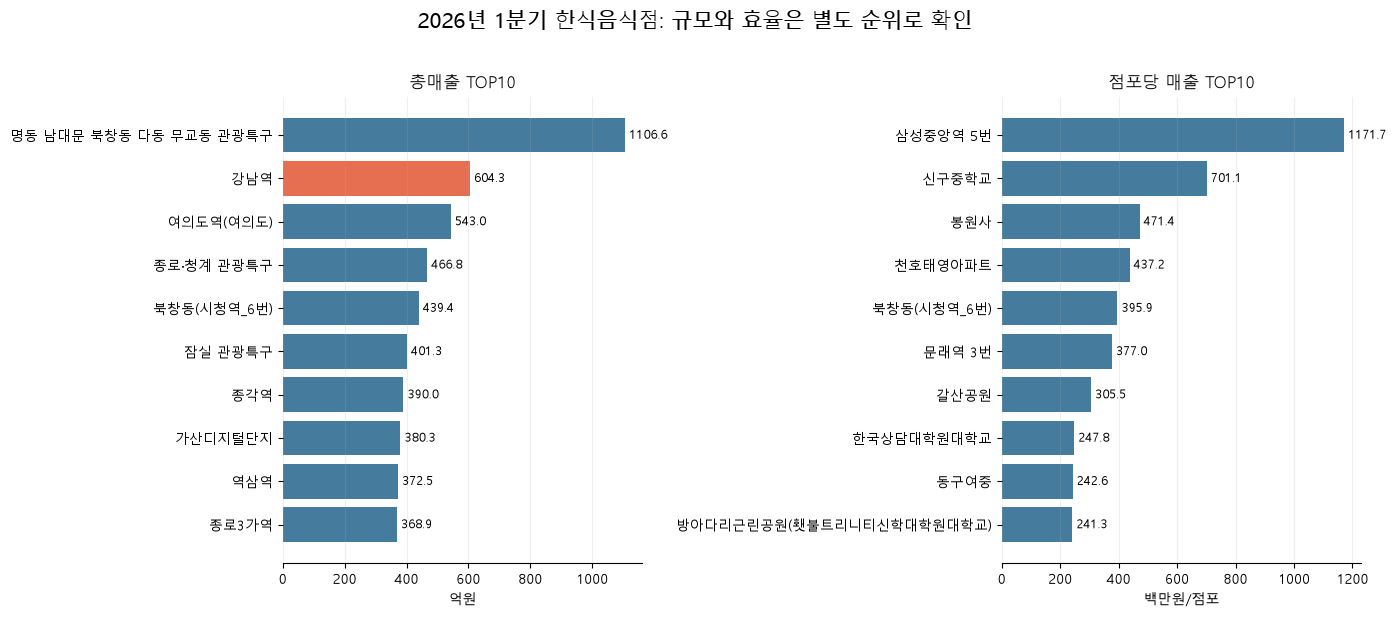

In [6]:
def plot_ranking(ax, data, metric, scale, title, unit):
    plot_df = data.iloc[::-1]
    values = plot_df[metric] / scale
    colors = []
    for name in plot_df["상권_명"]:
        colors.append("#E76F51" if name == selected_trade_area else "#457B9D")
    bars = ax.barh(plot_df["상권_명"], values, color=colors)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right", "left"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_ranking(axes[0], total_top_df, "분기_매출_금액", 100_000_000, "총매출 TOP10", "억원")
plot_ranking(axes[1], efficiency_top_df, "분기_점포당_매출", 1_000_000, "점포당 매출 TOP10", "백만원/점포")
fig.suptitle(f"{reference_period_label} {selected_industry}: 규모와 효율은 별도 순위로 확인", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 3. 실제 지도에서 본 상권 분포

점 크기는 총매출 규모, 색상은 공식 상권유형을 나타낸다. 마우스를 올리면 상권별 핵심 지표를 확인할 수 있으며, 선택 상권은 붉은색으로 강조한다.

In [7]:
map_df = sample_df.dropna(subset=["경도", "위도"]).copy()
map_df["분기 매출(억원)"] = map_df["분기_매출_금액"] / 100_000_000
map_df["점포당 매출(백만원)"] = map_df["분기_점포당_매출"] / 1_000_000
selected_point = map_df.loc[map_df["상권_명"].eq(selected_trade_area)].iloc[0]

map_fig = px.scatter_map(
    map_df,
    lat="위도",
    lon="경도",
    color="상권_구분_명",
    size="분기_매출_금액",
    size_max=28,
    hover_name="상권_명",
    hover_data={
        "자치구_명": True,
        "상권_구분_명": True,
        "분기 매출(억원)": ":,.1f",
        "점포당 매출(백만원)": ":,.1f",
        "유사업종_점포_수": ":,.0f",
        "분기_매출_금액": False,
        "위도": False,
        "경도": False,
    },
    labels={
        "상권_구분_명": "상권유형",
        "자치구_명": "자치구",
        "유사업종_점포_수": "유사업종 점포 수",
    },
    center={"lat": map_df["위도"].mean(), "lon": map_df["경도"].mean()},
    zoom=9.5,
    height=700,
    opacity=0.82,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
map_fig.add_trace(
    go.Scattermap(
        lat=[selected_point["위도"]],
        lon=[selected_point["경도"]],
        mode="markers+text",
        marker={"size": 26, "color": "#D62828", "opacity": 1.0},
        text=[selected_trade_area],
        textposition="top right",
        textfont={"size": 15, "color": "#B91C1C"},
        below="",
        name=selected_trade_area,
        hovertemplate=(
            f"<b>{selected_trade_area}</b><br>"
            f"분기 매출: {selected_point['분기 매출(억원)']:,.1f}억원<br>"
            f"점포당 매출: {selected_point['점포당 매출(백만원)']:,.1f}백만원<extra></extra>"
        ),
    )
)
map_fig.update_layout(
    title={"text": f"{reference_period_label} {selected_industry} 상권 위치와 총매출 규모", "x": 0.5},
    map_style="carto-positron",
    legend_title_text="상권유형",
    margin={"l": 0, "r": 0, "t": 60, "b": 0},
)
map_fig.show()

## 4. 선택 상권 결과

전체 상권 순위와 같은 공식 상권유형 안의 백분위를 함께 확인한다.

In [8]:
selected_row = sample_df.loc[sample_df["상권_명"].eq(selected_trade_area)].iloc[0]
volume_rank = int(selected_row["총매출_전체_순위"])
efficiency_rank = int(selected_row["점포당매출_전체_순위"])
peer_count = int(selected_row["동일유형_비교_상권_수"])
growth_rate = selected_row["매출_전년동기_증감률"]
growth_label = f"{growth_rate:,.1f}%" if pd.notna(growth_rate) else "계산 불가"

summary_df = pd.DataFrame({
    "지표": [
        "상권유형 / 자치구", "분기 매출", "유사업종 점포 수", "점포당 분기 매출",
        "총 유동인구", "총 상주인구", "매출 전년 동기 증감률",
        "최근 4분기 매출 증가 횟수", "연속 매출 증가 분기 수",
        "총매출 전체 순위", "점포당 매출 전체 순위",
        "총매출 동일유형 백분위", "점포당 매출 동일유형 백분위",
    ],
    "값": [
        f"{selected_row['상권_구분_명']} / {selected_row['자치구_명']}",
        f"{selected_row['분기_매출_금액'] / 100_000_000:,.1f}억원",
        f"{selected_row['유사업종_점포_수']:,.0f}개",
        f"{selected_row['분기_점포당_매출'] / 1_000_000:,.1f}백만원/점포",
        f"{selected_row['총_유동인구_수']:,.0f}명",
        f"{selected_row['총_상주인구_수']:,.0f}명",
        growth_label,
        f"{selected_row['최근_4분기_매출_증가_횟수']:,.0f}회",
        f"{selected_row['연속_매출_증가_분기_수']:,.0f}분기",
        f"{volume_rank}위 / {len(sample_df):,}개",
        f"{efficiency_rank}위 / {len(sample_df):,}개",
        f"{selected_row['총매출_동일유형_백분위']:,.1f} / 100 ({peer_count}개 비교)",
        f"{selected_row['점포당매출_동일유형_백분위']:,.1f} / 100 ({peer_count}개 비교)",
    ],
})
display(summary_df)

if pd.isna(growth_rate):
    growth_description = "계산할 수 없다"
elif growth_rate >= 0:
    growth_description = f"{growth_label} 증가했다"
else:
    growth_description = f"{growth_label} 감소했다"

def percentile_level(value):
    if value >= 80:
        return "상위권"
    if value >= 40:
        return "중간권"
    return "하위권"

volume_level = percentile_level(selected_row["총매출_동일유형_백분위"])
efficiency_level = percentile_level(selected_row["점포당매출_동일유형_백분위"])
if volume_level == efficiency_level:
    position_summary = f"시장 규모와 점포당 매출 효율이 모두 {volume_level}"
else:
    position_summary = f"시장 규모는 {volume_level}, 점포당 매출 효율은 {efficiency_level}"
display(Markdown(
    f"""### 1단계 해석
- **규모:** {selected_trade_area}은(는) 총매출 기준 전체 {len(sample_df):,}개 상권 중 **{volume_rank}위**, 동일 `{selected_row['상권_구분_명']}` 내 **{selected_row['총매출_동일유형_백분위']:.1f}백분위**다.
- **효율:** 점포당 매출 기준 전체 **{efficiency_rank}위**, 동일 유형 내 **{selected_row['점포당매출_동일유형_백분위']:.1f}백분위**다.
- **변화:** 전년 동기 대비 매출은 **{growth_description}**. 매출 변화의 구성은 다음 단계에서 점포 수·점포당 거래건수·객단가로 나누어 살펴본다.

#### 쉽게 말하면
**{selected_trade_area}은 같은 유형 상권과 비교할 때 {position_summary}이다.** 순위가 높더라도 비용을 뺀 이익이나 개별 점포의 성공을 보장하는 것은 아니다.

> TOP10과 백분위는 탐색용 비교 결과이며, 비용·수익성·개별 점포 차이를 반영한 출점 추천은 아니다."""
))

,지표,값
0,상권유형 / 자치구,발달상권 / 서초구
1,분기 매출,604.3억원
2,유사업종 점포 수,489개
3,점포당 분기 매출,123.6백만원/점포
4,총 유동인구,"7,710,017명"
5,총 상주인구,"6,248명"
6,매출 전년 동기 증감률,7.1%
7,최근 4분기 매출 증가 횟수,2회
8,연속 매출 증가 분기 수,0분기
9,총매출 전체 순위,"2위 / 1,404개"


### 1단계 해석
- **규모:** 강남역은(는) 총매출 기준 전체 1,404개 상권 중 **2위**, 동일 `발달상권` 내 **100.0백분위**다.
- **효율:** 점포당 매출 기준 전체 **101위**, 동일 유형 내 **86.2백분위**다.
- **변화:** 전년 동기 대비 매출은 **7.1% 증가했다**. 매출 변화의 구성은 다음 단계에서 점포 수·점포당 거래건수·객단가로 나누어 살펴본다.

#### 쉽게 말하면
**강남역은 같은 유형 상권과 비교할 때 시장 규모와 점포당 매출 효율이 모두 상위권이다.** 순위가 높더라도 비용을 뺀 이익이나 개별 점포의 성공을 보장하는 것은 아니다.

> TOP10과 백분위는 탐색용 비교 결과이며, 비용·수익성·개별 점포 차이를 반영한 출점 추천은 아니다.

# 서울 상권 분석 2단계: 성장 해부 — 매출 변화의 구성

**분석 질문:** 매출 변화는 점포수·점포당 거래건수·객단가 중 무엇으로 구성됐는가?

선택 상권·업종의 매출 변화를 **점포 수, 점포당 거래건수, 평균 객단가**로 나누고 최근 8분기의 방향과 지속성을 확인한다.

- 분석 대상: 핵심_분석_가능_여부가 True인 선택 상권·업종
- 성장 비교: 선택 기준분기와 전년 동기
- 추세 범위: 선택 기준분기까지 최근 8분기

## 분석용 파생변수 산식

총매출을 **점포 수 × 점포당 거래건수 × 평균 객단가**로 보고 다음 값을 계산한다.

- **점포 수 기여도** = 100 × ln(기준분기 점포 수 / 전년 동기 점포 수)
- **거래량 기여도** = 100 × ln(기준분기 점포당 거래건수 / 전년 동기 점포당 거래건수)
- **객단가 기여도** = 100 × ln(기준분기 평균 객단가 / 전년 동기 평균 객단가)
- 세 기여도의 합은 **총매출 로그 변화량** 100 × ln(기준분기 총매출 / 전년 동기 총매출)과 같다.
> **포인트:** 100 × 로그 변화량을 읽기 쉽게 나타낸 값으로, 변화가 작을 때는 일반 증감률(%)과 비슷하다.
- **분기 추세율** = 최근 8분기 로그 매출의 분기 순서 회귀기울기 b를 100 × (exp(b) - 1)로 변환한 값
- **전년 동기 증감률 변동성** = 최근 8분기 매출 전년 동기 증감률의 표준편차
- 총매출이 증가했을 때 양(+)의 구성요소가 하나면 해당 요소 성장형, 둘 이상이면 동반 성장형으로 구분한다.

> 이 계산은 관측된 매출 변화의 회계적 구성을 나누는 것으로 각 요소의 인과효과를 의미하지 않는다.

In [9]:
prior_year_quarter = f"{reference_year - 1}{reference_quarter_number}"
area_mask = commercial_df["상권_코드"] == selected_trade_area_code
industry_mask = commercial_df["서비스_업종_명"] == selected_industry
available_mask = commercial_df["핵심_분석_가능_여부"].eq(True)
past_mask = commercial_df["기준_년분기_코드"] <= reference_quarter
growth_df = commercial_df[area_mask & industry_mask & available_mask & past_mask].copy()
growth_df = growth_df.sort_values("기준_년분기_코드")

trend_df = growth_df[growth_df["기준_년분기_코드"].isin(recent_8_quarters)].copy()
if trend_df["기준_년분기_코드"].tolist() != recent_8_quarters:
    raise ValueError(f"최근 8분기가 연속되지 않습니다: {trend_df['기준_년분기_코드'].tolist()}")
quarter_labels = []
for value in trend_df["기준_년분기_코드"]:
    quarter_labels.append(f"{value[:4]}년 {int(value[-1])}분기")
trend_df["분기_표시"] = quarter_labels
period_rows = growth_df.set_index("기준_년분기_코드")
current_row = period_rows.loc[reference_quarter]
previous_row = period_rows.loc[prior_year_quarter]

# 총매출 변화를 세 구성요소로 나누어 각각 계산한다.
store_contribution = 100 * np.log(
    current_row["유사업종_점포_수"] / previous_row["유사업종_점포_수"]
)
transaction_contribution = 100 * np.log(
    current_row["분기_점포당_매출_건수"] / previous_row["분기_점포당_매출_건수"]
)
ticket_contribution = 100 * np.log(
    current_row["평균_객단가"] / previous_row["평균_객단가"]
)
contribution_df = pd.DataFrame({
    "구성 요소": ["점포 수", "점포당 거래건수", "평균 객단가"],
    "로그 성장 기여도": [store_contribution, transaction_contribution, ticket_contribution],
})
total_log_change = 100 * np.log(current_row["분기_매출_금액"] / previous_row["분기_매출_금액"])

positive_components = contribution_df[contribution_df["로그 성장 기여도"] > 0]["구성 요소"].tolist()
single_growth_types = {"점포 수": "점포 확장형", "점포당 거래건수": "거래량 성장형", "평균 객단가": "객단가 성장형"}
if total_log_change <= 0:
    growth_type = "감소·정체형"
elif len(positive_components) == 1:
    growth_type = single_growth_types[positive_components[0]]
else:
    growth_type = "동반 성장형"

quarter_order = np.arange(len(trend_df))
log_sales = np.log(trend_df["분기_매출_금액"])
trend_slope = np.polyfit(quarter_order, log_sales, 1)[0]
quarterly_trend_rate = 100 * np.expm1(trend_slope)
yoy_volatility = trend_df["매출_전년동기_증감률"].std(ddof=0)

,지표,값,단위
0,매출 전년 동기 증감률,7.1,%
1,점포 수 성장 기여도,2.5,포인트
2,점포당 거래건수 성장 기여도,6.2,포인트
3,평균 객단가 성장 기여도,-1.8,포인트
4,총매출 로그 변화,6.8,포인트
5,최근 8분기 분기 추세율,1.0,%/분기
6,전년 동기 증감률 변동성,3.7,%p
7,최근 4분기 매출 증가 횟수,2.0,회
8,연속 매출 증가 분기 수,0.0,분기


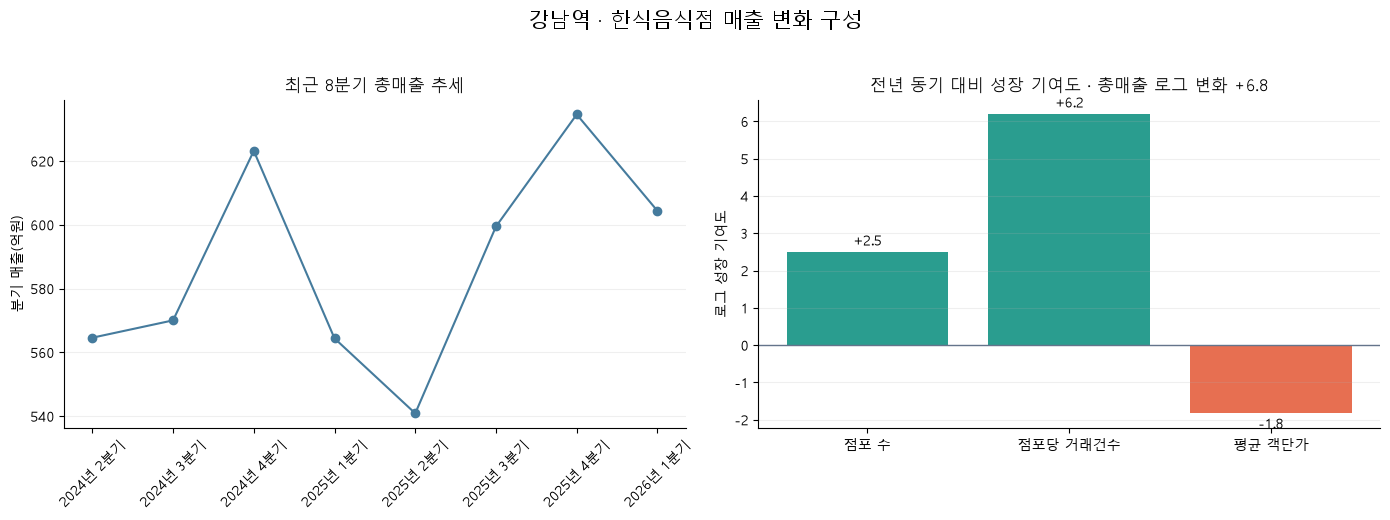

### 2단계 해석
- **성장 내용:** 2026년 1분기 총매출은 전년 동기보다 **+7.1%** 변했고, 분류 결과는 **동반 성장형**이다.
- **변화 구성:** 점포 수 +2.5, 점포당 거래건수 +6.2, 평균 객단가 -1.8이며, 로그 변화 폭이 가장 큰 구성요소는 **점포당 거래건수**이다.
- **8분기 흐름:** 로그 매출 추세는 분기당 **1.0% 상승** 방향이며, 전년 동기 증감률 변동성은 **3.7%p**다.
- **지속성:** 최근 4분기 중 매출 증가 분기는 **2회**, 현재 연속 증가 기간은 **0분기**다.

#### 쉽게 말하면
**매출을 구성하는 세 요소 중 가장 크게 움직인 부분은 점포당 거래건수의 증가다.** 최근 분기까지 매출 증가가 연속해서 이어진 상태는 아니다.

> 성장 기여도는 양수 값의 로그 변화에서 정확히 합산되는 회계적 분해다. 각 요소가 매출 변화를 일으켰다는 인과효과나 개별 점포의 향후 성장을 의미하지 않는다.

In [10]:
numeric_rows = [
    ("매출 전년 동기 증감률", current_row["매출_전년동기_증감률"], "%"),
    ("점포 수 성장 기여도", store_contribution, "포인트"),
    ("점포당 거래건수 성장 기여도", transaction_contribution, "포인트"),
    ("평균 객단가 성장 기여도", ticket_contribution, "포인트"),
    ("총매출 로그 변화", total_log_change, "포인트"),
    ("최근 8분기 분기 추세율", quarterly_trend_rate, "%/분기"),
    ("전년 동기 증감률 변동성", yoy_volatility, "%p"),
    ("최근 4분기 매출 증가 횟수", current_row["최근_4분기_매출_증가_횟수"], "회"),
    ("연속 매출 증가 분기 수", current_row["연속_매출_증가_분기_수"], "분기"),
]
numeric_result_df = pd.DataFrame(numeric_rows, columns=["지표", "값", "단위"])
display(numeric_result_df.style.format({"값": "{:,.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(trend_df["분기_표시"], trend_df["분기_매출_금액"] / 100_000_000, marker="o", color="#457B9D")
axes[0].set(title="최근 8분기 총매출 추세", ylabel="분기 매출(억원)")
axes[0].tick_params(axis="x", rotation=45)

colors = []
for value in contribution_df["로그 성장 기여도"]:
    colors.append("#2A9D8F" if value >= 0 else "#E76F51")
bars = axes[1].bar(contribution_df["구성 요소"], contribution_df["로그 성장 기여도"], color=colors)
axes[1].bar_label(bars, fmt="%+.1f", padding=3)
axes[1].axhline(0, color="#64748B", linewidth=1)
axes[1].set(
    title=f"전년 동기 대비 성장 기여도 · 총매출 로그 변화 {total_log_change:+.1f}",
    ylabel="로그 성장 기여도",
)
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"{selected_trade_area} · {selected_industry} 매출 변화 구성", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

sales_yoy_rate = current_row["매출_전년동기_증감률"]
recent_growth_count = int(current_row["최근_4분기_매출_증가_횟수"])
consecutive_growth_quarters = int(current_row["연속_매출_증가_분기_수"])
largest_component_row = contribution_df.loc[contribution_df["로그 성장 기여도"].abs().idxmax()]
largest_component = largest_component_row["구성 요소"]
largest_component_direction = "증가" if largest_component_row["로그 성장 기여도"] >= 0 else "감소"
contribution_parts = []
for _, row in contribution_df.iterrows():
    text = f"{row['구성 요소']} {row['로그 성장 기여도']:+.1f}"
    contribution_parts.append(text)
contribution_text = ", ".join(contribution_parts)
trend_direction = "상승" if quarterly_trend_rate >= 0 else "하락"
if consecutive_growth_quarters > 0:
    continuity_summary = f"최근 {consecutive_growth_quarters}분기 연속으로 매출이 늘었다."
else:
    continuity_summary = "최근 분기까지 매출 증가가 연속해서 이어진 상태는 아니다."
display(Markdown(
    f"""### 2단계 해석
- **성장 내용:** {reference_period_label} 총매출은 전년 동기보다 **{sales_yoy_rate:+.1f}%** 변했고, 분류 결과는 **{growth_type}**이다.
- **변화 구성:** {contribution_text}이며, 로그 변화 폭이 가장 큰 구성요소는 **{largest_component}**이다.
- **8분기 흐름:** 로그 매출 추세는 분기당 **{abs(quarterly_trend_rate):.1f}% {trend_direction}** 방향이며, 전년 동기 증감률 변동성은 **{yoy_volatility:.1f}%p**다.
- **지속성:** 최근 4분기 중 매출 증가 분기는 **{recent_growth_count}회**, 현재 연속 증가 기간은 **{consecutive_growth_quarters}분기**다.

#### 쉽게 말하면
**매출을 구성하는 세 요소 중 가장 크게 움직인 부분은 {largest_component}의 {largest_component_direction}다.** {continuity_summary}

> 성장 기여도는 양수 값의 로그 변화에서 정확히 합산되는 회계적 분해다. 각 요소가 매출 변화를 일으켰다는 인과효과나 개별 점포의 향후 성장을 의미하지 않는다."""
))

# 서울 상권 분석 3단계: 방문과 소비 구성 비교

**분석 질문:** 수요와 점포의 성장, 방문자와 매출 구성은 어떻게 다르게 나타나는가?

선택 상권·업종에서 **유동인구 증가가 점포 증가를 앞섰는지**, 방문자 구성이 실제 매출 구성과 얼마나 비슷한지 확인한다.

## 분석용 파생변수 산식

- **수요–점포 성장 격차(G)** = 유동인구 전년 동기 증감률 - 점포 수 전년 동기 증감률 (%p)
  - 양수이면 유동인구가, 음수이면 점포 수가 상대적으로 더 빠르게 증가했다.
- **구성 차이 지수(T)** = 1/2 × Σ|매출 비중 - 유동인구 비중|
  - 0에 가까울수록 두 구성이 비슷하며, 1에 가까울수록 차이가 크다.
- **매출 과대표 비율(R)** = 매출 비중 / 유동인구 비중 (유동인구 비중 > 0인 항목만 계산)
  - 1보다 크면 해당 항목의 매출 비중이 유동인구 비중보다 높다.

> 매출 과대표 비율은 구성비 비교 지표이며, 방문자가 실제 구매한 비율을 뜻하는 전환율은 아니다.

In [11]:
quarter_mask = selected_segment_history_df["기준_년분기_코드"] == reference_quarter
area_mask = selected_segment_history_df["상권_코드"] == selected_trade_area_code
available_mask = selected_segment_history_df["구성비_비교_가능_여부"].eq(True)
composition_df = selected_segment_history_df[quarter_mask & area_mask & available_mask].copy()
composition_labels = {"gender": "성별", "age": "연령", "weekday": "요일", "time_band": "시간대"}
composition_order = list(composition_labels.values())
composition_df["구성 기준"] = composition_df["구성_유형"].map(composition_labels)

# 구성 기준별 매출 비중과 유동인구 비중의 차이를 계산한다.
composition_df["비중 차이 절댓값"] = composition_df["매출_유동인구_비중_차이"].abs()
distance_by_type = composition_df.groupby("구성 기준")["비중 차이 절댓값"].sum() / 2
distance_by_type = distance_by_type.reindex(composition_order)
distance_df = distance_by_type.reset_index(name="구성 차이 지수")
top_ratio_df = composition_df.nlargest(8, "매출_유동인구_비중_비율").copy()

correlation_source_df = growth_df[["기준_년분기_코드", "분기_매출_금액", "총_유동인구_수"]].dropna().copy()
correlation_source_df["이전_유동인구"] = correlation_source_df["총_유동인구_수"].shift(1)
correlation_source_df["분기_간격"] = (
    correlation_source_df["기준_년분기_코드"].map(quarter_to_ordinal).diff()
)
same_quarter_correlation = correlation_source_df["분기_매출_금액"].corr(correlation_source_df["총_유동인구_수"])
lag_correlation_source = correlation_source_df.loc[correlation_source_df["분기_간격"].eq(1)]
lagged_correlation = lag_correlation_source["분기_매출_금액"].corr(lag_correlation_source["이전_유동인구"])
correlation_result_df = pd.DataFrame({
    "관계": ["동일 분기 유동인구–매출", "직전 분기 유동인구–현재 매출"],
    "피어슨 상관계수": [same_quarter_correlation, lagged_correlation],
    "사용 분기 수": [len(correlation_source_df), len(lag_correlation_source)],
})

selected_commercial_row = selected_row


### 수치 결과

,지표,값,단위
0,유동인구 전년 동기 증감률,-2.0,%
1,점포 수 전년 동기 증감률,2.5,%
2,수요–점포 성장 격차,-4.5,%p


,구성 기준,구성 차이 지수
0,성별,0.091
1,연령,0.134
2,요일,0.080
3,시간대,0.354


#### 유동인구–매출 보조 상관

,관계,피어슨 상관계수,사용 분기 수
0,동일 분기 유동인구–매출,0.847,21
1,직전 분기 유동인구–현재 매출,0.633,20


#### 매출 과대표 비율 상위 항목

,구성 기준,구성 항목,매출 비중(%),유동인구 비중(%),매출 과대표 비율
156470,시간대,21~24시,24.2,9.8,2.48
156469,시간대,17~21시,39.4,22.4,1.76
156454,연령,30대,36.9,25.9,1.42
156463,요일,토요일,17.2,12.6,1.36
156467,시간대,11~14시,22.4,18.4,1.22
156456,연령,50대,13.3,11.1,1.20
156450,성별,남성,58.0,48.9,1.19
156462,요일,금요일,19.6,16.5,1.18


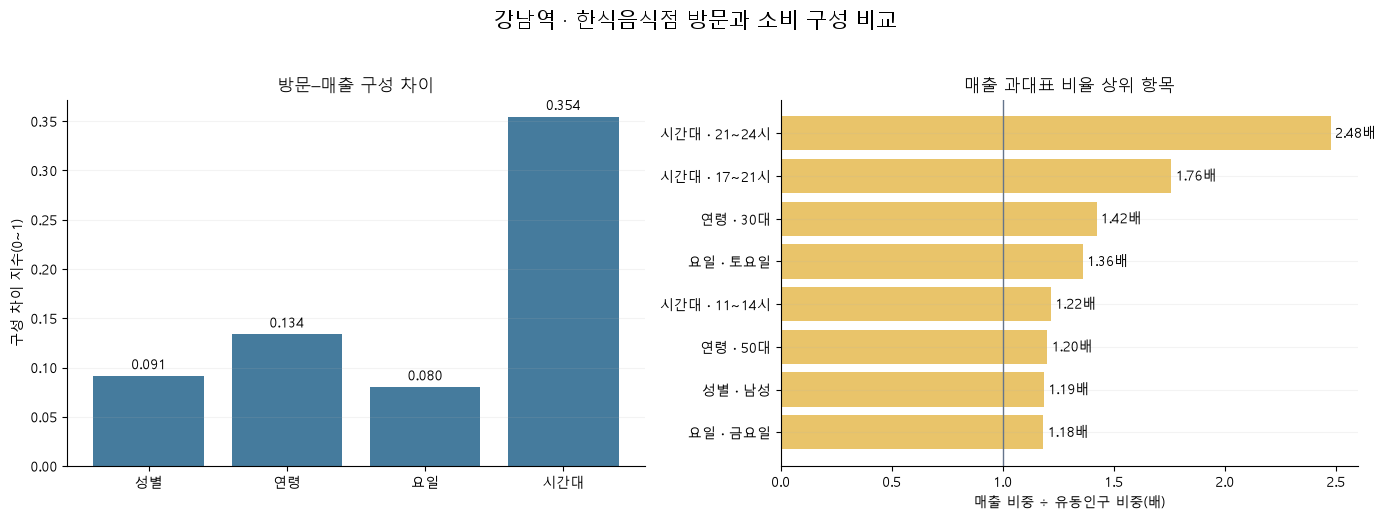

### 3단계 해석
- **성장 관계:** 수요–점포 성장 격차는 **-4.5%p**로, 전년 동기 대비 **점포 수가 유동인구보다 빠르게 증가**했다.
- **구성 차이:** 방문과 매출 구성의 차이는 **시간대**에서 가장 크고(T=0.354), **요일**에서 가장 작다(T=0.080).
- **상대적으로 높은 매출 비중:** **시간대 · 21~24시**의 매출 과대표 비율이 **2.48배**로 가장 높다.
- **보조 상관:** 동일 분기 상관은 **0.847**, 직전 분기 유동인구와 현재 매출의 상관은 **0.633**다. 방향을 살펴보는 보조 결과이며 시차가 인과성을 만들지는 않는다.

#### 쉽게 말하면
**강남역은 전년보다 점포 수가 유동인구보다 빠르게 증가한 상권이다.** 특히 시간대의 21~24시는 방문 비중보다 매출 비중이 상대적으로 크게 나타났다.

> 이 결과는 방문자와 매출의 집계 구성 차이를 보여준다. 동일인이 방문 후 구매했는지는 식별할 수 없으므로 실제 구매 전환율로 해석하지 않는다.

In [12]:
growth_gap_df = pd.DataFrame([
    ("유동인구 전년 동기 증감률", selected_commercial_row["유동인구_전년동기_증감률"], "%"),
    ("점포 수 전년 동기 증감률", selected_commercial_row["점포_전년동기_증감률"], "%"),
    ("수요–점포 성장 격차", selected_commercial_row["수요_점포_전년동기_증감률_차이"], "%p"),
], columns=["지표", "값", "단위"])
ratio_result_df = top_ratio_df[["구성 기준", "구성_명", "매출_금액_비중", "유동인구_비중", "매출_유동인구_비중_비율"]].copy()
ratio_result_df[["매출_금액_비중", "유동인구_비중"]] *= 100
ratio_result_df.columns = ["구성 기준", "구성 항목", "매출 비중(%)", "유동인구 비중(%)", "매출 과대표 비율"]

display(Markdown("### 수치 결과"))
display(growth_gap_df.style.format({"값": "{:,.1f}"}))
display(distance_df.style.format({"구성 차이 지수": "{:.3f}"}))
display(Markdown("#### 유동인구–매출 보조 상관"))
display(correlation_result_df.style.format({"피어슨 상관계수": "{:.3f}"}))
display(Markdown("#### 매출 과대표 비율 상위 항목"))
display(ratio_result_df.style.format({"매출 비중(%)": "{:.1f}", "유동인구 비중(%)": "{:.1f}", "매출 과대표 비율": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
distance_bars = axes[0].bar(distance_df["구성 기준"], distance_df["구성 차이 지수"], color="#457B9D")
axes[0].bar_label(distance_bars, fmt="%.3f", padding=3)
axes[0].set(title="방문–매출 구성 차이", ylabel="구성 차이 지수(0~1)")

plot_ratio_df = ratio_result_df.sort_values("매출 과대표 비율")
ratio_labels = plot_ratio_df["구성 기준"] + " · " + plot_ratio_df["구성 항목"]
ratio_bars = axes[1].barh(ratio_labels, plot_ratio_df["매출 과대표 비율"], color="#E9C46A")
axes[1].bar_label(ratio_bars, fmt="%.2f배", padding=3)
axes[1].axvline(1, color="#64748B", linewidth=1)
axes[1].set(title="매출 과대표 비율 상위 항목", xlabel="매출 비중 ÷ 유동인구 비중(배)")
for ax in axes:
    ax.grid(axis="y", alpha=0.15)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"{selected_trade_area} · {selected_industry} 방문과 소비 구성 비교", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

growth_gap = selected_commercial_row["수요_점포_전년동기_증감률_차이"]
gap_interpretation = "유동인구가 점포 수보다 빠르게 증가" if growth_gap >= 0 else "점포 수가 유동인구보다 빠르게 증가"
largest_distance = distance_df.loc[distance_df["구성 차이 지수"].idxmax()]
smallest_distance = distance_df.loc[distance_df["구성 차이 지수"].idxmin()]
top_ratio = ratio_result_df.iloc[0]
display(Markdown(
    f"""### 3단계 해석
- **성장 관계:** 수요–점포 성장 격차는 **{growth_gap:+.1f}%p**로, 전년 동기 대비 **{gap_interpretation}**했다.
- **구성 차이:** 방문과 매출 구성의 차이는 **{largest_distance['구성 기준']}**에서 가장 크고(T={largest_distance['구성 차이 지수']:.3f}), **{smallest_distance['구성 기준']}**에서 가장 작다(T={smallest_distance['구성 차이 지수']:.3f}).
- **상대적으로 높은 매출 비중:** **{top_ratio['구성 기준']} · {top_ratio['구성 항목']}**의 매출 과대표 비율이 **{top_ratio['매출 과대표 비율']:.2f}배**로 가장 높다.
- **보조 상관:** 동일 분기 상관은 **{same_quarter_correlation:.3f}**, 직전 분기 유동인구와 현재 매출의 상관은 **{lagged_correlation:.3f}**다. 방향을 살펴보는 보조 결과이며 시차가 인과성을 만들지는 않는다.

#### 쉽게 말하면
**{selected_trade_area}은 전년보다 {gap_interpretation}한 상권이다.** 특히 {top_ratio['구성 기준']}의 {top_ratio['구성 항목']}는 방문 비중보다 매출 비중이 상대적으로 크게 나타났다.

> 이 결과는 방문자와 매출의 집계 구성 차이를 보여준다. 동일인이 방문 후 구매했는지는 식별할 수 없으므로 실제 구매 전환율로 해석하지 않는다."""
))


# 서울 상권 분석 4단계: 경쟁 진단

**분석 질문:** 같은 업종에서 점포가 밀집한 상권일수록 총매출과 점포당 매출은 어떻게 나타나는가?

기준분기·선택 업종의 상권을 **점포밀도(1ha당 점포 수)** 순서로 정렬한 뒤, 상권 수가 비슷한 5개 그룹으로 나눈다. 이후 각 그룹의 **총매출 중앙값**과 **점포당 매출 중앙값**을 비교한다. 중앙값은 일부 매우 큰 상권의 영향을 덜 받는 대표값이다.

> 이 단계는 유동인구·상권면적·입지 같은 다른 조건을 따로 고려하지 않은 단순 비교다. 따라서 그룹 간 차이를 점포밀도의 인과효과로 해석하지 않는다.

,점포밀도 수준,점포밀도 범위(점포/ha),표본 수,총매출 중앙값(억원),점포당 매출 중앙값(백만원)
0,낮음,0.08~1.23,281,2.8,37.5
1,낮은 편,1.23~1.99,281,5.7,37.5
2,중간,2.00~3.27,280,10.1,43.7
3,높은 편,3.28~5.68,281,17.5,55.4
4,높음,5.73~53.53,281,21.8,62.9


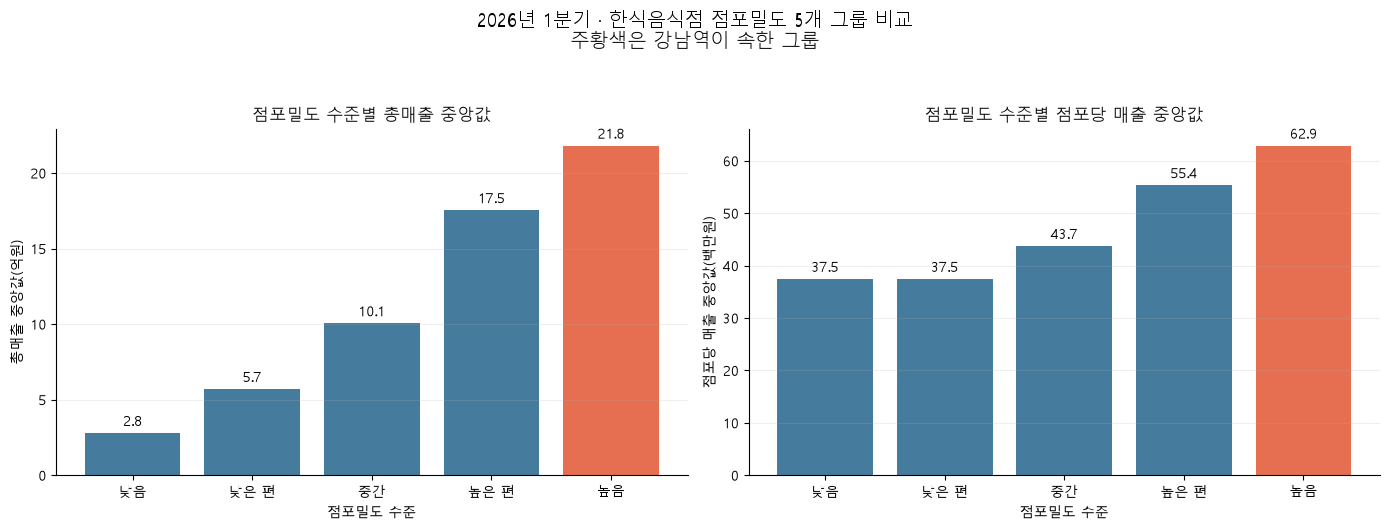

### 4단계 해석
- **비교 방법:** 같은 분기·업종의 1,404개 상권을 점포밀도 순으로 나누어 그룹당 약 281개씩 비교했다.
- **총매출:** 밀도 **높음** 그룹의 중앙값은 **21.8억원**으로, **낮음** 그룹의 **2.8억원**보다 **7.8배** 높았다.
- **점포당 매출:** 밀도 **높음** 그룹의 중앙값은 **62.9백만원**으로, **낮음** 그룹의 **37.5백만원**보다 **1.7배** 높았다.
- **선택 상권:** 강남역은 같은 업종에서 점포밀도 **높음** 그룹에 속한다.

#### 쉽게 말하면
**강남역의 동종 업종 점포 밀도는 높음 수준이지만, 이번 비교에서는 점포가 밀집한 상권의 시장 규모와 점포당 매출도 함께 높았다.** 따라서 점포가 많다는 사실만으로 경쟁이 과도하거나 유리하다고 판단할 수 없다.

> 현재 자료에서는 점포가 밀집한 그룹에 총매출과 점포당 매출이 높은 상권이 함께 나타났다. 이는 그룹 간 관찰된 차이이며, 점포를 늘리면 매출이 오른다는 뜻은 아니다.

In [13]:
# 같은 분기·업종에서 점포밀도와 매출을 비교할 수 있는 상권만 사용한다.
competition_columns = ["점포_밀도", "분기_매출_금액", "분기_점포당_매출"]
competition_df = sample_df.dropna(subset=competition_columns).copy()
positive_mask = competition_df[competition_columns].gt(0).all(axis=1)
competition_df = competition_df[positive_mask].copy()
competition_df = competition_df.sort_values(["점포_밀도", "상권_코드"])

# 점포밀도가 낮은 순서부터 상권 수가 비슷한 5개 그룹으로 나눈다.
density_group_order = ["낮음", "낮은 편", "중간", "높은 편", "높음"]
density_rank = competition_df["점포_밀도"].rank(method="first")
competition_df["밀도 그룹"] = pd.qcut(
    density_rank,
    q=5,
    labels=density_group_order,
)

# 각 그룹의 표본 수, 점포밀도 범위, 매출 중앙값을 계산한다.
competition_summary_df = (
    competition_df.groupby("밀도 그룹", observed=True)
    .agg(
        표본수=("상권_코드", "size"),
        밀도_최솟값=("점포_밀도", "min"),
        밀도_중앙값=("점포_밀도", "median"),
        밀도_최댓값=("점포_밀도", "max"),
        총매출_중앙값=("분기_매출_금액", "median"),
        점포당매출_중앙값=("분기_점포당_매출", "median"),
    )
    .reset_index()
)

density_ranges = []
for _, row in competition_summary_df.iterrows():
    density_range = f"{row['밀도_최솟값']:.2f}~{row['밀도_최댓값']:.2f}"
    density_ranges.append(density_range)

competition_table = pd.DataFrame({
    "점포밀도 수준": competition_summary_df["밀도 그룹"],
    "점포밀도 범위(점포/ha)": density_ranges,
    "표본 수": competition_summary_df["표본수"],
    "총매출 중앙값(억원)": competition_summary_df["총매출_중앙값"] / 100_000_000,
    "점포당 매출 중앙값(백만원)": competition_summary_df["점포당매출_중앙값"] / 1_000_000,
})
display(competition_table.style.format({
    "총매출 중앙값(억원)": "{:.1f}",
    "점포당 매출 중앙값(백만원)": "{:.1f}",
}))

# 선택 상권이 속한 그룹을 확인하고 그래프에서 주황색으로 표시한다.
selected_density_group = competition_df.loc[
    competition_df["상권_코드"] == selected_trade_area_code,
    "밀도 그룹",
].iloc[0]
selected_density_group = str(selected_density_group)

bar_colors = []
for group_name in density_group_order:
    if group_name == selected_density_group:
        bar_colors.append("#E76F51")
    else:
        bar_colors.append("#457B9D")

# 개별 상권 산점도 대신 5개 그룹의 중앙값을 직접 비교한다.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_sales_values = competition_summary_df["총매출_중앙값"] / 100_000_000
total_bars = axes[0].bar(
    competition_summary_df["밀도 그룹"],
    total_sales_values,
    color=bar_colors,
)
axes[0].bar_label(total_bars, fmt="%.1f", padding=3)
axes[0].set(
    title="점포밀도 수준별 총매출 중앙값",
    xlabel="점포밀도 수준",
    ylabel="총매출 중앙값(억원)",
)

sales_per_store_values = competition_summary_df["점포당매출_중앙값"] / 1_000_000
efficiency_bars = axes[1].bar(
    competition_summary_df["밀도 그룹"],
    sales_per_store_values,
    color=bar_colors,
)
axes[1].bar_label(efficiency_bars, fmt="%.1f", padding=3)
axes[1].set(
    title="점포밀도 수준별 점포당 매출 중앙값",
    xlabel="점포밀도 수준",
    ylabel="점포당 매출 중앙값(백만원)",
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    f"{reference_period_label} · {selected_industry} 점포밀도 5개 그룹 비교\n"
    f"주황색은 {selected_trade_area}이 속한 그룹",
    fontsize=14,
    y=1.05,
)
fig.tight_layout()
plt.show()

# 가장 낮은 그룹과 가장 높은 그룹의 차이를 이해하기 쉬운 배수로 요약한다.
low_group = competition_summary_df.iloc[0]
high_group = competition_summary_df.iloc[-1]
total_sales_multiple = high_group["총매출_중앙값"] / low_group["총매출_중앙값"]
sales_per_store_multiple = (
    high_group["점포당매출_중앙값"] / low_group["점포당매출_중앙값"]
)

display(Markdown(
    f"""### 4단계 해석
- **비교 방법:** 같은 분기·업종의 {len(competition_df):,}개 상권을 점포밀도 순으로 나누어 그룹당 약 {len(competition_df) / 5:,.0f}개씩 비교했다.
- **총매출:** 밀도 **높음** 그룹의 중앙값은 **{high_group['총매출_중앙값'] / 100_000_000:.1f}억원**으로, **낮음** 그룹의 **{low_group['총매출_중앙값'] / 100_000_000:.1f}억원**보다 **{total_sales_multiple:.1f}배** 높았다.
- **점포당 매출:** 밀도 **높음** 그룹의 중앙값은 **{high_group['점포당매출_중앙값'] / 1_000_000:.1f}백만원**으로, **낮음** 그룹의 **{low_group['점포당매출_중앙값'] / 1_000_000:.1f}백만원**보다 **{sales_per_store_multiple:.1f}배** 높았다.
- **선택 상권:** {selected_trade_area}은 같은 업종에서 점포밀도 **{selected_density_group}** 그룹에 속한다.

#### 쉽게 말하면
**{selected_trade_area}의 동종 업종 점포 밀도는 {selected_density_group} 수준이지만, 이번 비교에서는 점포가 밀집한 상권의 시장 규모와 점포당 매출도 함께 높았다.** 따라서 점포가 많다는 사실만으로 경쟁이 과도하거나 유리하다고 판단할 수 없다.

> 현재 자료에서는 점포가 밀집한 그룹에 총매출과 점포당 매출이 높은 상권이 함께 나타났다. 이는 그룹 간 관찰된 차이이며, 점포를 늘리면 매출이 오른다는 뜻은 아니다."""
))

# 서울 상권 분석 5단계: 상권 구조

**분석 질문:** 선택 상권은 이용 시간·배후·주거·접근·경쟁 측면에서 어떤 환경인가?

5단계에서는 선택 상권의 이용 시간·배후·주거·접근·경쟁 환경을 **같은 업종·같은 상권 유형** 안에서 비교한다. 시간대와 경쟁 지표는 기준분기 값을, 비교적 천천히 변하는 인구·가구·시설 지표는 최근 4분기 중앙값을 사용한다. 백분위는 상대적 위치일 뿐 성과의 원인이나 우열을 뜻하지 않는다.

**원자료 한계로 비교에서 제외:** 아파트 가구 비중

,영역,지표,선택 상권 값,단위,동일 유형 내 백분위
0,이용 시간,주말 유동 비중,22.00,%,17.8
1,이용 시간,점심 유동 비중,18.41,%,78.5
2,이용 시간,저녁 유동 비중,22.36,%,90.9
3,이용 시간,심야 유동 비중,21.64,%,20.7
4,배후,상주인구,"6,248.00",명,94.6
5,배후,직장인구,"87,191.00",명,97.9
6,배후,상주인구 대비 직장인구 비율,0.07,배,17.8
7,주거,가구 수,"4,046.00",가구,93.0
8,접근,집객시설 밀도,6.30,개/ha,90.1
9,접근,지하철역 수,2.00,개,88.4


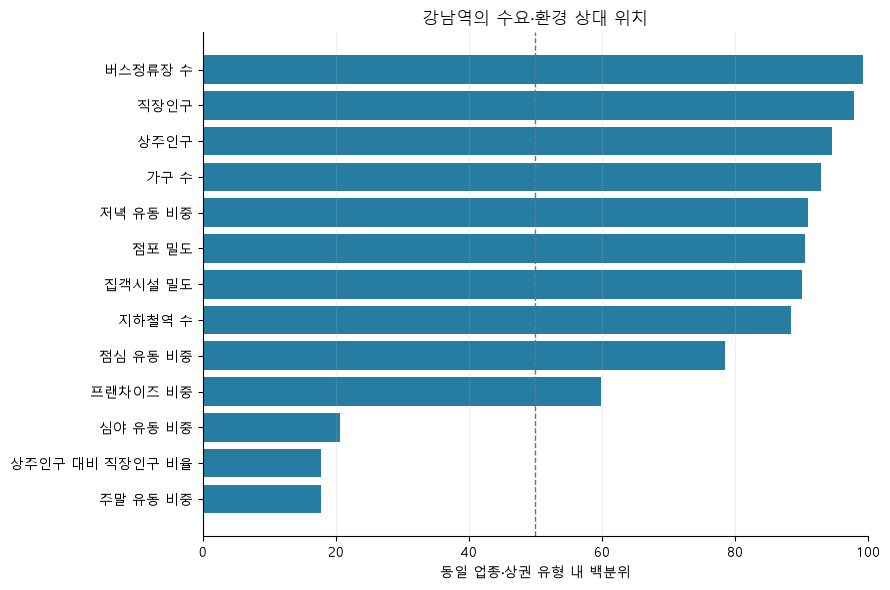

### 5단계 해석
- **비교 기준:** 한식음식점 · 발달상권 242개 상권
- **상대적으로 높은 맥락 지표:** 버스정류장 수, 직장인구, 상주인구

#### 쉽게 말하면
**강남역은 같은 유형 상권과 비교할 때 버스정류장 수, 직장인구, 상주인구 조건이 특히 두드러진다.** 이 지표들은 상권의 환경을 설명하지만, 그 자체가 매출이 높은 원인이라는 뜻은 아니다.

> 이 결과는 선택 상권이 어떤 수요·환경 맥락에 놓였는지 보여주는 기술적 비교다. 각 지표가 매출을 만들었다는 인과 해석은 하지 않으며, 여러 조건을 함께 고려한 관계는 6단계에서 확인한다.

In [14]:
# 기준분기의 요일·시간대별 유동인구 비중을 상권별 한 행으로 정리한다.
quarter_mask = selected_segment_history_df["기준_년분기_코드"] == reference_quarter
available_mask = selected_segment_history_df["구성비_비교_가능_여부"].eq(True)
time_mask = selected_segment_history_df["구성_유형"].isin(["weekday", "time_band"])
eligible_mask = selected_segment_history_df["상권_코드"].isin(eligible_trade_area_codes)

time_rows = selected_segment_history_df[quarter_mask & available_mask & time_mask & eligible_mask]
time_rows = time_rows[["상권_코드", "구성_코드", "유동인구_비중"]]
time_pivot = time_rows.pivot(index="상권_코드", columns="구성_코드", values="유동인구_비중")

time_profile_df = pd.DataFrame(index=time_pivot.index)
time_profile_df["주말_유동인구_비중"] = time_pivot["sat"] + time_pivot["sun"]
time_profile_df["점심_유동인구_비중"] = time_pivot["11_14"]
time_profile_df["저녁_유동인구_비중"] = time_pivot["17_21"]
time_profile_df["심야_유동인구_비중"] = time_pivot["21_24"] + time_pivot["00_06"]
time_profile_df = time_profile_df.reset_index()

slow_columns = [
    "총_상주인구_수", "총_직장인구_수", "상주인구_대비_직장인구_비율", "총_가구_수",
    "아파트_가구_비중", "집객시설_밀도", "지하철역_수", "버스정류장_수",
]
recent_4q_mask = industry_history_df["기준_년분기_코드"].isin(recent_8_quarters[-4:])
eligible_mask = industry_history_df["상권_코드"].isin(eligible_trade_area_codes)
complete_mask = industry_history_df["필수행_완전"]
slow_rows = industry_history_df[recent_4q_mask & eligible_mask & complete_mask]
slow_rows = slow_rows[["상권_코드"] + slow_columns]
slow_context_df = slow_rows.groupby("상권_코드", as_index=False)[slow_columns].median()
current_context_df = sample_df.loc[
    sample_df["상권_코드"].isin(eligible_trade_area_codes),
    ["상권_코드", "상권_명", "상권_구분_명", "점포_밀도", "프랜차이즈_비중"],
]
context_df = (
    current_context_df.merge(slow_context_df, on="상권_코드", how="inner")
    .merge(time_profile_df, on="상권_코드", how="inner")
)
selected_area_type = selected_row["상권_구분_명"]
peer_context_df = context_df[context_df["상권_구분_명"] == selected_area_type].copy()
selected_context = peer_context_df[peer_context_df["상권_코드"] == selected_trade_area_code].iloc[0]

# 영역, 원본 컬럼, 표시명, 값 변환 배수, 단위를 한곳에서 관리한다.
context_definitions = [
    ("이용 시간", "주말_유동인구_비중", "주말 유동 비중", 100, "%"),
    ("이용 시간", "점심_유동인구_비중", "점심 유동 비중", 100, "%"),
    ("이용 시간", "저녁_유동인구_비중", "저녁 유동 비중", 100, "%"),
    ("이용 시간", "심야_유동인구_비중", "심야 유동 비중", 100, "%"),
    ("배후", "총_상주인구_수", "상주인구", 1, "명"),
    ("배후", "총_직장인구_수", "직장인구", 1, "명"),
    ("배후", "상주인구_대비_직장인구_비율", "상주인구 대비 직장인구 비율", 1, "배"),
    ("주거", "총_가구_수", "가구 수", 1, "가구"),
    ("주거", "아파트_가구_비중", "아파트 가구 비중", 100, "%"),
    ("접근", "집객시설_밀도", "집객시설 밀도", 1, "개/ha"),
    ("접근", "지하철역_수", "지하철역 수", 1, "개"),
    ("접근", "버스정류장_수", "버스정류장 수", 1, "개"),
    ("경쟁", "점포_밀도", "점포 밀도", 1, "점포/ha"),
    ("경쟁", "프랜차이즈_비중", "프랜차이즈 비중", 100, "%"),
]

context_rows = []
unavailable_context_metrics = []
for area, metric, label, scale, unit in context_definitions:
    if peer_context_df[metric].nunique(dropna=True) < 2:
        unavailable_context_metrics.append(label)
        continue

    percentile_column = f"{metric}_백분위"
    peer_context_df[percentile_column] = peer_context_df[metric].rank(method="average", pct=True) * 100
    context_rows.append({
        "영역": area,
        "지표": label,
        "선택 상권 값": selected_context[metric] * scale,
        "단위": unit,
        "동일 유형 내 백분위": peer_context_df.loc[selected_context.name, percentile_column],
    })

if unavailable_context_metrics:
    excluded_text = ", ".join(unavailable_context_metrics)
    display(Markdown(f"**원자료 한계로 비교에서 제외:** {excluded_text}"))

context_result_df = pd.DataFrame(context_rows)
display(context_result_df.style.format({"선택 상권 값": "{:,.2f}", "동일 유형 내 백분위": "{:.1f}"}))

context_plot_df = context_result_df.sort_values("동일 유형 내 백분위")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(context_plot_df["지표"], context_plot_df["동일 유형 내 백분위"], color="#277DA1")
ax.axvline(50, color="#64748B", linestyle="--", linewidth=1)
ax.set(xlim=(0, 100), xlabel="동일 업종·상권 유형 내 백분위", title=f"{selected_trade_area}의 수요·환경 상대 위치")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

high_context = context_result_df.nlargest(3, "동일 유형 내 백분위")["지표"].tolist()
display(Markdown(
    f"""### 5단계 해석
- **비교 기준:** {selected_industry} · {selected_area_type} {len(peer_context_df):,}개 상권
- **상대적으로 높은 맥락 지표:** {', '.join(high_context)}

#### 쉽게 말하면
**{selected_trade_area}은 같은 유형 상권과 비교할 때 {', '.join(high_context)} 조건이 특히 두드러진다.** 이 지표들은 상권의 환경을 설명하지만, 그 자체가 매출이 높은 원인이라는 뜻은 아니다.

> 이 결과는 선택 상권이 어떤 수요·환경 맥락에 놓였는지 보여주는 기술적 비교다. 각 지표가 매출을 만들었다는 인과 해석은 하지 않으며, 여러 조건을 함께 고려한 관계는 6단계에서 확인한다."""
))

# 서울 상권 분석 6단계: EBM 기반 효율 요인 진단

**분석 질문:** 다른 조건을 함께 고려했을 때 어떤 요인이 점포당 매출 예측에 참고가 되는가?

모든 상권·업종·분기를 하나의 **Explainable Boosting Machine(EBM)**으로 학습한다. 과거 분기로 학습하고 최신 분기는 검증에만 사용해 시간 순서를 지키며, 예측 대상은 로그 점포당 매출이다. 모든 요인은 개별 효과로 포함하고, 2개 요인의 상호작용은 EBM이 변수 수만큼(`interactions="1x"`) 자동 선별한다.

- **학습:** 2021년 1분기~2025년 4분기
- **검증:** 2026년 1분기
- **성능 확인:** 검증 R²와 중앙 절대 오차율
- **항 중요도:** EBM이 전체 학습 표본의 예측에 각 항을 얼마나 크게 사용했는지 비교
- **항별 예측 기여값:** 선택 상권 한 건의 예측값을 각 항이 얼마나 올리거나 내렸는지 분해

### 항 중요도 산출 방법

InterpretML의 공식 명칭은 **항 중요도(term importance)**다. 여기서 `항(term)`은 개별 변수와 EBM이 선택한 2개 변수의 상호작용을 모두 포함한다. `영향도`는 인과효과로 오해할 수 있어 사용하지 않는다.

EBM은 각 표본의 로그 점포당 매출 예측을 다음과 같이 만든다.

`로그 예측값 = 절편 + 개별 변수 항의 점수 합 + 상호작용 항의 점수 합`

1. **항 중요도** = 학습 표본에서 해당 항의 예측 점수 절댓값을 평균한 값이다. 양수와 음수가 상쇄되지 않으므로 예측을 자주 크게 바꾸는 항일수록 높다.
2. **전체 중요도 비중** = 각 항 중요도를 모든 항 중요도의 합으로 나누어 100을 곱한 값이다. 여러 항을 같은 척도로 비교하기 위해 이 분석에서 추가한 상대 비중이다.
3. **높은 20%–낮은 20% 예측 차이** = 연속형 변수의 상위 20%와 하위 20%에서 해당 개별 변수 항의 평균 점수 차이를 매출 비율로 환산한 값이다. 상호작용 효과는 포함하지 않는다.
4. **선택 상권 항별 예측 기여값** = 선택 상권에서 각 항이 로그 예측값에 실제로 더하거나 뺀 값이다. 매출 비율 환산값은 `exp(기여값)-1`로 계산하며, 여러 항의 환산값은 서로 더하지 않는다.

> 항 중요도 비중은 매출 변화율이나 R² 기여율이 아니며 방향도 나타내지 않는다. 항별 예측 기여값 역시 모델의 예측 근거이지 인과효과·통계적 유의성·출점 추천을 의미하지 않는다. 서로 연관된 변수들은 중요도를 나누어 가질 수 있다.

In [15]:
# 1) 모든 업종·분기의 요일 및 시간대 유동인구 비중을 준비한다.
model_industries = sorted(commercial_df["서비스_업종_명"].dropna().unique())
model_quarters = sorted(commercial_df["기준_년분기_코드"].dropna().unique())
needed_time_codes = ["sat", "sun", "11_14", "17_21", "21_24", "00_06"]
time_columns = [
    "기준_년분기_코드", "상권_코드", "서비스_업종_명",
    "구성_유형", "구성_코드", "유동인구_비중", "구성비_비교_가능_여부",
]

time_parts = []
time_reader = pd.read_csv(
    data_dir / "구성비_비교데이터.csv",
    usecols=time_columns,
    dtype={"기준_년분기_코드": "string", "상권_코드": "string"},
    chunksize=200_000,
    low_memory=False,
)
for chunk in time_reader:
    quarter_mask = chunk["기준_년분기_코드"].isin(model_quarters)
    industry_mask = chunk["서비스_업종_명"].isin(model_industries)
    type_mask = chunk["구성_유형"].isin(["weekday", "time_band"])
    code_mask = chunk["구성_코드"].isin(needed_time_codes)
    available_mask = chunk["구성비_비교_가능_여부"].eq(True)
    selected_rows = chunk[quarter_mask & industry_mask & type_mask & code_mask & available_mask]
    if len(selected_rows) > 0:
        time_parts.append(selected_rows[time_columns[:-1]])

model_time_long_df = pd.concat(time_parts, ignore_index=True)
time_keys = ["기준_년분기_코드", "상권_코드", "서비스_업종_명"]
time_pivot = model_time_long_df.pivot(
    index=time_keys,
    columns="구성_코드",
    values="유동인구_비중",
).reset_index()

model_time_df = time_pivot[time_keys].copy()
model_time_df["주말 유동 비중"] = time_pivot["sat"] + time_pivot["sun"]
model_time_df["점심 유동 비중"] = time_pivot["11_14"]
model_time_df["저녁 유동 비중"] = time_pivot["17_21"]
model_time_df["심야 유동 비중"] = time_pivot["21_24"] + time_pivot["00_06"]

# 2) 분석 가능한 상권×업종×분기와 시간 구성 자료를 결합한다.
source_count = len(commercial_df)
model_source_df = commercial_df[commercial_df["전체_분석_가능_여부"].eq(True)].copy()
available_count = len(model_source_df)

positive_columns = ["분기_점포당_매출", "면적_헥타르", "점포_밀도"]
positive_mask = model_source_df[positive_columns].notna().all(axis=1)
positive_mask &= model_source_df[positive_columns].gt(0).all(axis=1)
model_source_df = model_source_df[positive_mask].copy()
positive_count = len(model_source_df)

model_df = model_source_df.merge(model_time_df, on=time_keys, how="inner")
time_merged_count = len(model_df)

# 3) EBM 입력변수를 만든다. 규모가 큰 변수는 로그로 변환한다.
model_df["로그 점포당 매출"] = np.log(model_df["분기_점포당_매출"])
model_df["로그 유동인구"] = np.log1p(model_df["총_유동인구_수"])
model_df["로그 상주인구"] = np.log1p(model_df["총_상주인구_수"])
model_df["로그 직장인구"] = np.log1p(model_df["총_직장인구_수"])
model_df["로그 가구 수"] = np.log1p(model_df["총_가구_수"])
model_df["로그 상권면적"] = np.log(model_df["면적_헥타르"])
model_df["로그 집객시설 밀도"] = np.log1p(model_df["집객시설_밀도"])
model_df["지하철역 수"] = model_df["지하철역_수"]
model_df["버스정류장 수"] = model_df["버스정류장_수"]
model_df["로그 점포밀도"] = np.log1p(model_df["점포_밀도"])
model_df["프랜차이즈 비중"] = model_df["프랜차이즈_비중"]
model_df["시간 순서"] = model_df["기준_년분기_코드"].map(quarter_to_ordinal)
model_df["시간 순서"] -= model_df["시간 순서"].min()
model_df["업종"] = model_df["서비스_업종_명"].astype(str)
model_df["자치구"] = model_df["자치구_명"].astype(str)
model_df["상권 유형"] = model_df["상권_구분_명"].astype(str)
model_df["분기"] = model_df["기준_년분기_코드"].str[-1].astype(str) + "분기"

numeric_features = [
    "로그 유동인구", "로그 상주인구", "로그 직장인구", "로그 가구 수",
    "주말 유동 비중", "점심 유동 비중", "저녁 유동 비중", "심야 유동 비중",
    "로그 상권면적", "로그 집객시설 밀도", "지하철역 수", "버스정류장 수",
    "로그 점포밀도", "프랜차이즈 비중", "시간 순서",
]
categorical_features = ["업종", "자치구", "상권 유형", "분기"]
feature_columns = numeric_features + categorical_features
feature_types = ["continuous"] * len(numeric_features) + ["nominal"] * len(categorical_features)

feature_group_map = {
    "로그 유동인구": "수요", "로그 상주인구": "배후", "로그 직장인구": "배후",
    "로그 가구 수": "주거", "주말 유동 비중": "이용 시간", "점심 유동 비중": "이용 시간",
    "저녁 유동 비중": "이용 시간", "심야 유동 비중": "이용 시간",
    "로그 상권면적": "상권 구조", "로그 집객시설 밀도": "접근",
    "지하철역 수": "접근", "버스정류장 수": "접근",
    "로그 점포밀도": "경쟁", "프랜차이즈 비중": "경쟁",
    "시간 순서": "시점 통제", "업종": "업종 통제", "자치구": "지역 통제",
    "상권 유형": "유형 통제", "분기": "계절 통제",
}
control_features = ["시간 순서", "업종", "자치구", "상권 유형", "분기"]

required_columns = ["로그 점포당 매출", *feature_columns]
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=required_columns).copy()
model_df = model_df.sort_values(
    ["기준_년분기_코드", "서비스_업종_명", "상권_코드"]
).reset_index(drop=True)
final_model_count = len(model_df)

# 아파트 가구 비중은 전 표본에서 값이 같아 모델 입력에서 제외한다.
display(Markdown(
    "**입력 제외:** 아파트 가구 비중은 유효 표본에서 값의 변동이 없어 학습 정보가 없습니다. "
    "상주인구 대비 직장인구 비율은 두 인구 변수를 다시 조합한 값이므로 중복 산입하지 않습니다. "
    "매출·거래건수·객단가·점포당 유동인구처럼 결과변수와 직접 연결된 파생지표도 누수를 피하기 위해 사용하지 않습니다."
))

# 4) 과거 분기는 학습, 최신 분기는 검증으로 분리한다.
train_df = model_df[model_df["기준_년분기_코드"] < reference_quarter].copy()
test_df = model_df[model_df["기준_년분기_코드"] == reference_quarter].copy()
if len(train_df) == 0 or len(test_df) == 0:
    raise ValueError("학습 또는 최신 분기 검증 표본이 없습니다.")

X_train = train_df[feature_columns].copy()
y_train = train_df["로그 점포당 매출"].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df["로그 점포당 매출"].copy()

sample_flow_df = pd.DataFrame({
    "단계": [
        "입력 상권×업종×분기", "전체 분석 가능", "Y·면적·밀도 양수",
        "시간 구성 결합", "EBM 완전 사례",
    ],
    "행 수": [
        source_count, available_count, positive_count, time_merged_count, final_model_count,
    ],
})
sample_flow_df["직전 단계 제외"] = sample_flow_df["행 수"].shift(fill_value=source_count) - sample_flow_df["행 수"]

split_summary_df = pd.DataFrame({
    "구분": ["학습", "최신 분기 검증"],
    "기간": [f"{model_df['기준_년분기_코드'].min()}~{train_df['기준_년분기_코드'].max()}", reference_quarter],
    "표본 수": [len(train_df), len(test_df)],
    "업종 수": [train_df["업종"].nunique(), test_df["업종"].nunique()],
    "상권 수": [train_df["상권_코드"].nunique(), test_df["상권_코드"].nunique()],
})

display(Markdown("### 학습 표본"))
display(sample_flow_df)
display(split_summary_df)

**입력 제외:** 아파트 가구 비중은 유효 표본에서 값의 변동이 없어 학습 정보가 없습니다. 상주인구 대비 직장인구 비율은 두 인구 변수를 다시 조합한 값이므로 중복 산입하지 않습니다. 매출·거래건수·객단가·점포당 유동인구처럼 결과변수와 직접 연결된 파생지표도 누수를 피하기 위해 사용하지 않습니다.

### 학습 표본

,단계,행 수,직전 단계 제외
0,입력 상권×업종×분기,92749,0
1,전체 분석 가능,69840,22909
2,Y·면적·밀도 양수,69840,0
3,시간 구성 결합,69840,0
4,EBM 완전 사례,69840,0


,구분,기간,표본 수,업종 수,상권 수
0,학습,20211~20254,66569,3,1455
1,최신 분기 검증,20261,3271,3,1399


### EBM 학습 설정

,설정,적용값,적용 이유
0,개별 변수 구간,256,연속형 분포를 충분히 나누되 지나치게 잘게 쪼개지 않음
1,상호작용 구간,32,2차원 조합별 표본이 너무 작아지는 것을 방지
2,자동 상호작용 수,변수 수와 동일(19개),모든 조합을 후보로 평가하고 해석 가능한 수만 자동 선택
3,최소 잎 표본,20,소수 관측치에만 맞춘 규칙을 제한
4,외부 배깅,8,표본 재추출로 중요도와 곡선을 안정화
5,학습률,0.03,완만하게 학습해 과적합을 줄임
6,최대 반복,8000,내부 검증 조기 종료를 적용할 충분한 상한


### 모델 성능

,구분,표본 수,로그 R²,중앙 절대 오차율
0,학습,66569,0.641,37.9%
1,최신 분기 검증,3271,0.587,40.5%


### 개별 변수 항 중요도

...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


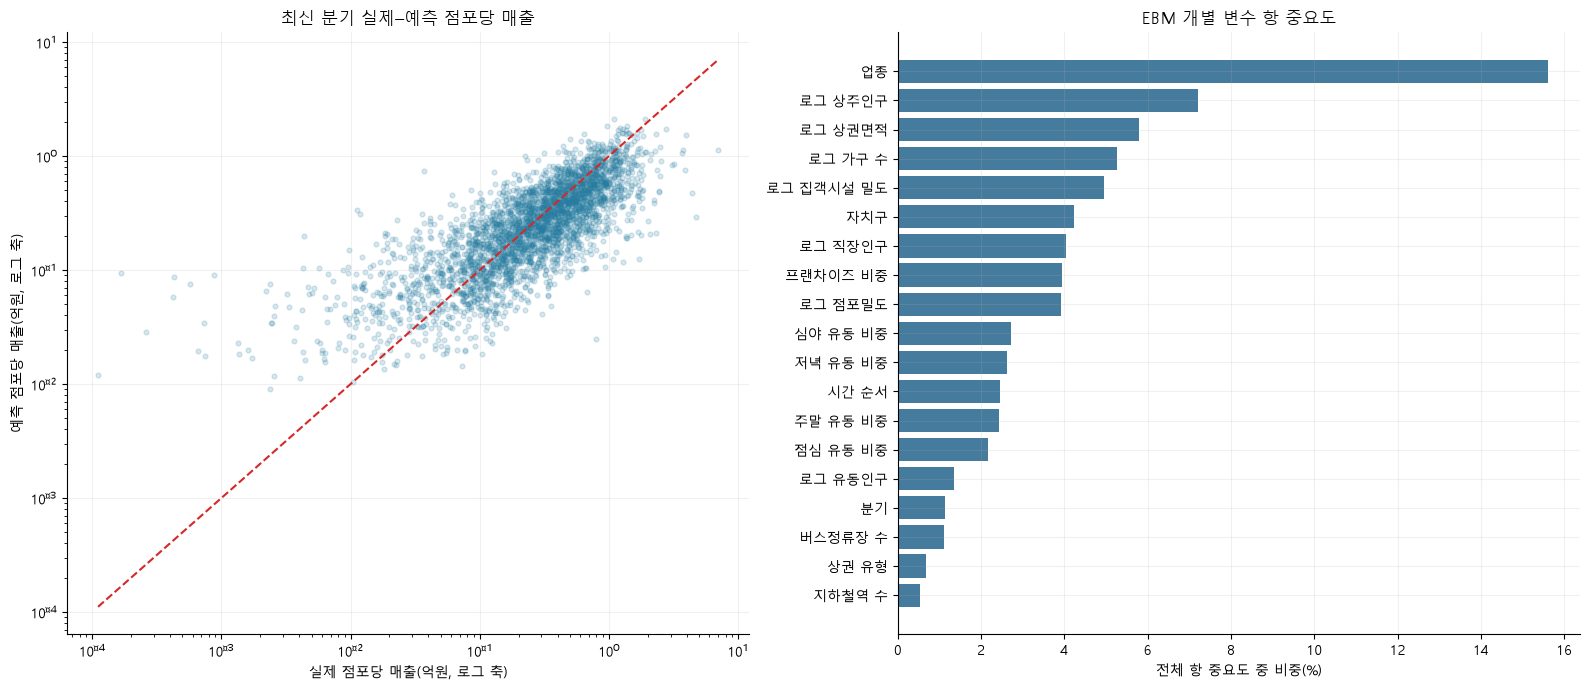

In [16]:
# 표본 규모(학습 6만여 행)와 변수 유형에 맞춘 EBM 설정
ebm_parameters = {
    "interactions": "1x",
    "max_bins": 256,
    "max_interaction_bins": 32,
    "validation_size": 0.15,
    "outer_bags": 8,
    "learning_rate": 0.03,
    "max_rounds": 8000,
    "early_stopping_rounds": 100,
    "min_samples_leaf": 20,
    "max_leaves": 3,
    "smoothing_rounds": 300,
    "interaction_smoothing_rounds": 100,
    "n_jobs": -2,
    "random_state": 42,
}
parameter_reason_df = pd.DataFrame({
    "설정": [
        "개별 변수 구간", "상호작용 구간", "자동 상호작용 수",
        "최소 잎 표본", "외부 배깅", "학습률", "최대 반복",
    ],
    "적용값": [
        ebm_parameters["max_bins"], ebm_parameters["max_interaction_bins"],
        f"변수 수와 동일({len(feature_columns)}개)", ebm_parameters["min_samples_leaf"],
        ebm_parameters["outer_bags"], ebm_parameters["learning_rate"],
        ebm_parameters["max_rounds"],
    ],
    "적용 이유": [
        "연속형 분포를 충분히 나누되 지나치게 잘게 쪼개지 않음",
        "2차원 조합별 표본이 너무 작아지는 것을 방지",
        "모든 조합을 후보로 평가하고 해석 가능한 수만 자동 선택",
        "소수 관측치에만 맞춘 규칙을 제한",
        "표본 재추출로 중요도와 곡선을 안정화",
        "완만하게 학습해 과적합을 줄임",
        "내부 검증 조기 종료를 적용할 충분한 상한",
    ],
})
display(Markdown("### EBM 학습 설정"))
display(parameter_reason_df)

ebm = ExplainableBoostingRegressor(
    feature_names=feature_columns,
    feature_types=feature_types,
    **ebm_parameters,
)
ebm.fit(X_train, y_train)

# 학습 및 최신 분기 검증 성능
train_prediction_log = ebm.predict(X_train)
test_prediction_log = ebm.predict(X_test)
train_actual_sales = np.exp(y_train.to_numpy())
test_actual_sales = np.exp(y_test.to_numpy())
train_predicted_sales = np.exp(train_prediction_log)
test_predicted_sales = np.exp(test_prediction_log)

def median_absolute_percentage_error(actual, predicted):
    percentage_error = np.abs(actual - predicted) / actual
    return np.median(percentage_error)

performance_df = pd.DataFrame({
    "구분": ["학습", "최신 분기 검증"],
    "표본 수": [len(X_train), len(X_test)],
    "로그 R²": [
        r2_score(y_train, train_prediction_log),
        r2_score(y_test, test_prediction_log),
    ],
    "중앙 절대 오차율": [
        median_absolute_percentage_error(train_actual_sales, train_predicted_sales),
        median_absolute_percentage_error(test_actual_sales, test_predicted_sales),
    ],
})
display(Markdown("### 모델 성능"))
display(performance_df.style.format({
    "로그 R²": "{:.3f}",
    "중앙 절대 오차율": "{:.1%}",
}))

# EBM이 학습한 모든 개별 변수 항과 상호작용 항의 중요도를 정리한다.
# InterpretML의 기본 항 중요도는 학습 표본에서 항별 점수 절댓값의 평균이다.
term_importance = ebm.term_importances(importance_type="avg_weight")
total_term_importance = term_importance.sum()
term_rows = []
for term_index, feature_indexes in enumerate(ebm.term_features_):
    term_name = ebm.term_names_[term_index]
    term_type = "개별 요인" if len(feature_indexes) == 1 else "상호작용"
    term_rows.append({
        "항목": term_name,
        "구분": term_type,
        "항 중요도": term_importance[term_index],
        "전체 중요도 비중": 100 * term_importance[term_index] / total_term_importance,
        "term_index": term_index,
    })
term_importance_df = pd.DataFrame(term_rows)
term_importance_df = term_importance_df.sort_values("항 중요도", ascending=False).reset_index(drop=True)

# 개별 변수 항은 모두 표시하고, 상위 20%와 하위 20%의 예측 차이도 비교한다.
train_term_scores = ebm.eval_terms(X_train)
main_rows = []
for feature_index, feature_name in enumerate(feature_columns):
    term_index = None
    for index, term_features in enumerate(ebm.term_features_):
        if tuple(term_features) == (feature_index,):
            term_index = index
            break

    term_row = term_importance_df[term_importance_df["term_index"] == term_index].iloc[0]
    direction_text = "범주별 차이"
    if feature_name in numeric_features:
        feature_values = X_train[feature_name].astype(float)
        low_cut = feature_values.quantile(0.20)
        high_cut = feature_values.quantile(0.80)
        low_score = train_term_scores[feature_values <= low_cut, term_index].mean()
        high_score = train_term_scores[feature_values >= high_cut, term_index].mean()
        high_low_difference = 100 * np.expm1(high_score - low_score)
        if high_low_difference >= 0:
            direction_text = f"상위 20%가 하위 20%보다 {abs(high_low_difference):.1f}% 높음"
        else:
            direction_text = f"상위 20%가 하위 20%보다 {abs(high_low_difference):.1f}% 낮음"

    main_rows.append({
        "영역": feature_group_map[feature_name],
        "변수": feature_name,
        "역할": "통제" if feature_name in control_features else "분석 요인",
        "전체 중요도 비중": term_row["전체 중요도 비중"],
        "높은 20%–낮은 20% 예측 차이": direction_text,
    })

main_importance_df = pd.DataFrame(main_rows)
main_importance_df = main_importance_df.sort_values("전체 중요도 비중", ascending=False).reset_index(drop=True)
interaction_importance_df = term_importance_df[term_importance_df["구분"] == "상호작용"].copy()

display(Markdown("### 개별 변수 항 중요도"))
display(main_importance_df.style.format({"전체 중요도 비중": "{:.1f}%"}))

# 최신 분기 실제값과 예측값, 개별 변수 항 중요도를 함께 시각화한다.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

actual_plot = test_actual_sales / 100_000_000
predicted_plot = test_predicted_sales / 100_000_000
axes[0].scatter(actual_plot, predicted_plot, s=12, alpha=0.18, color="#277DA1")
line_min = min(actual_plot.min(), predicted_plot.min())
line_max = max(actual_plot.max(), predicted_plot.max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="#D62828")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set(
    title="최신 분기 실제–예측 점포당 매출",
    xlabel="실제 점포당 매출(억원, 로그 축)",
    ylabel="예측 점포당 매출(억원, 로그 축)",
)

importance_plot_df = main_importance_df.sort_values("전체 중요도 비중")
axes[1].barh(
    importance_plot_df["변수"],
    importance_plot_df["전체 중요도 비중"],
    color="#457B9D",
)
axes[1].set(
    title="EBM 개별 변수 항 중요도",
    xlabel="전체 항 중요도 중 비중(%)",
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.18)

fig.tight_layout()
plt.show()

In [17]:
# EBM이 자동 선택한 상호작용 중 항 중요도가 큰 항목을 확인한다.
interaction_display_df = interaction_importance_df.head(10)[
    ["항목", "전체 중요도 비중"]
].copy()
display(Markdown(
    f"### 자동 선택 상호작용 상위 10개 "
    f"(전체 {len(interaction_importance_df)}개)"
))
display(interaction_display_df.style.format({"전체 중요도 비중": "{:.1f}%"}))

# 최신 분기의 선택 상권을 학습에 포함하지 않은 상태에서 진단한다.
selected_mask = (
    test_df["상권_코드"].eq(selected_trade_area_code)
    & test_df["서비스_업종_명"].eq(selected_industry)
)
selected_test_df = test_df[selected_mask].copy()
if len(selected_test_df) != 1:
    raise ValueError(
        f"최신 분기 선택 상권 표본을 하나로 확정할 수 없습니다: {len(selected_test_df)}행"
    )

selected_X = selected_test_df[feature_columns]
selected_actual_sales = selected_test_df["분기_점포당_매출"].iloc[0]
selected_prediction_log = ebm.predict(selected_X)[0]
selected_predicted_sales = np.exp(selected_prediction_log)
selected_prediction_error = selected_predicted_sales / selected_actual_sales - 1

selected_summary_df = pd.DataFrame({
    "실제 점포당 매출(억원)": [selected_actual_sales / 100_000_000],
    "EBM 예측 점포당 매출(억원)": [selected_predicted_sales / 100_000_000],
    "예측–실제 차이": [selected_prediction_error],
    "검증 분기": [reference_quarter],
})
display(Markdown(f"### 선택 상권 진단: {selected_trade_area} · {selected_industry}"))
display(selected_summary_df.style.format({
    "실제 점포당 매출(억원)": "{:.2f}",
    "EBM 예측 점포당 매출(억원)": "{:.2f}",
    "예측–실제 차이": "{:+.1%}",
}))

# 선택 상권 예측에 각 개별 변수 항과 상호작용 항이 더하거나 뺀 값을 계산한다.
selected_term_scores = ebm.eval_terms(selected_X)[0]
local_rows = []
for term_index, term_name in enumerate(ebm.term_names_):
    log_contribution = selected_term_scores[term_index]
    local_rows.append({
        "요인 또는 상호작용": term_name,
        "구분": "개별 요인" if len(ebm.term_features_[term_index]) == 1 else "상호작용",
        "로그 예측 기여값": log_contribution,
        "매출 비율 환산": 100 * np.expm1(log_contribution),
        "절대 로그 예측 기여값": abs(log_contribution),
    })

selected_contribution_df = pd.DataFrame(local_rows)
selected_contribution_df = selected_contribution_df.sort_values(
    "절대 로그 예측 기여값", ascending=False
).reset_index(drop=True)
display(Markdown("#### 선택 상권의 항별 예측 기여값 상위 10개"))
display(
    selected_contribution_df.head(10)[
        ["요인 또는 상호작용", "구분", "로그 예측 기여값", "매출 비율 환산"]
    ].style.format({
        "로그 예측 기여값": "{:+.3f}",
        "매출 비율 환산": "{:+.1f}%",
    })
)

# 해석에 사용할 전역·지역 요약
global_factor_df = main_importance_df[main_importance_df["역할"] == "분석 요인"]
top_global_factor_df = global_factor_df.head(5).copy()
top_interaction_df = interaction_importance_df.head(3).copy()
top_global_factors = top_global_factor_df["변수"].tolist()
simple_global_factors = []
for factor in top_global_factors[:3]:
    simple_global_factors.append(factor.replace("로그 " , ""))

global_factor_parts = []
for _, row in top_global_factor_df.iterrows():
    factor_name = row["변수"].replace("로그 ", "")
    factor_text = (
        f"{factor_name} {row['전체 중요도 비중']:.1f}% "
        f"({row['높은 20%–낮은 20% 예측 차이']})"
    )
    global_factor_parts.append(factor_text)
global_factor_text = ", ".join(global_factor_parts)
top_global_share = top_global_factor_df["전체 중요도 비중"].sum()

interaction_parts = []
for _, row in top_interaction_df.iterrows():
    interaction_parts.append(f"{row['항목']} {row['전체 중요도 비중']:.1f}%")
interaction_text = ", ".join(interaction_parts)
top_interaction_share = top_interaction_df["전체 중요도 비중"].sum()

positive_local = selected_contribution_df[selected_contribution_df["로그 예측 기여값"] > 0]
negative_local = selected_contribution_df[selected_contribution_df["로그 예측 기여값"] < 0]
positive_parts = []
for _, row in positive_local.head(3).iterrows():
    positive_parts.append(f"{row['요인 또는 상호작용']} {row['매출 비율 환산']:+.1f}%")
negative_parts = []
for _, row in negative_local.head(3).iterrows():
    negative_parts.append(f"{row['요인 또는 상호작용']} {row['매출 비율 환산']:+.1f}%")
positive_text = ", ".join(positive_parts)
negative_text = ", ".join(negative_parts)

test_r2 = performance_df.loc[
    performance_df["구분"] == "최신 분기 검증", "로그 R²"
].iloc[0]
test_mape = performance_df.loc[
    performance_df["구분"] == "최신 분기 검증", "중앙 절대 오차율"
].iloc[0]
if selected_prediction_error >= 0:
    prediction_comparison = f"모델 예상값이 실제보다 {abs(selected_prediction_error):.1%} 높았다"
else:
    prediction_comparison = f"모델 예상값이 실제보다 {abs(selected_prediction_error):.1%} 낮았다"

display(Markdown(
    f"""### 6단계 해석
- **최신 분기 설명력:** 학습에 사용하지 않은 {reference_period_label} {len(test_df):,}개 표본에서 로그 R²는 **{test_r2:.3f}**, 중앙 절대 오차율은 **{test_mape:.1%}**다.
- **주요 분석 요인의 항 중요도:** {global_factor_text}. 이 5개 항의 합은 전체 항 중요도의 **{top_global_share:.1f}%**다.
- **주요 상호작용의 항 중요도:** {interaction_text}. 이 3개 항의 합은 전체 항 중요도의 **{top_interaction_share:.1f}%**다.
- **선택 상권의 양(+) 예측 기여:** {positive_text}
- **선택 상권의 음(-) 예측 기여:** {negative_text}
- **선택 상권 예측:** {selected_trade_area}·{selected_industry}의 실제 점포당 매출은 **{selected_actual_sales / 100_000_000:.2f}억원**, EBM 예측은 **{selected_predicted_sales / 100_000_000:.2f}억원**으로 {prediction_comparison}.

#### 쉽게 말하면
**전체 항 중요도 중 {', '.join(simple_global_factors)} 등을 포함한 상위 5개 분석 요인이 {top_global_share:.1f}%를 차지했다.** {selected_trade_area}·{selected_industry}에서는 {prediction_comparison}. 다만 검증 표본의 중앙 오차율이 {test_mape:.1%}로 작지 않으므로 확정 판단이 아닌 참고용 진단으로 봐야 한다.

> 중요도 비중은 매출 변화율이나 R² 기여율이 아니며 방향도 나타내지 않는다. 높은 20%–낮은 20% 예측 차이는 해당 개별 변수 항만 비교한 값이다. 선택 상권의 매출 비율 환산값은 로그 예측 기여값을 이해하기 쉽게 바꾼 값으로 서로 합산하지 않는다. 이 결과는 인과효과나 통계적 유의성을 뜻하지 않으며, 실제 매출에는 임대료·점포 크기·브랜드·배달 매출 등 모델에 없는 조건도 작용한다."""
))

### 자동 선택 상호작용 상위 10개 (전체 19개)

,항목,전체 중요도 비중
10,로그 상주인구 & 로그 집객시설 밀도,2.6%
11,업종 & 자치구,2.6%
15,로그 집객시설 밀도 & 프랜차이즈 비중,2.4%
17,로그 집객시설 밀도 & 업종,1.9%
18,로그 상권면적 & 업종,1.9%
19,로그 유동인구 & 프랜차이즈 비중,1.6%
20,시간 순서 & 업종,1.6%
21,로그 점포밀도 & 업종,1.6%
22,버스정류장 수 & 업종,1.6%
23,로그 상주인구 & 업종,1.5%


### 선택 상권 진단: 강남역 · 한식음식점

,실제 점포당 매출(억원),EBM 예측 점포당 매출(억원),예측–실제 차이,검증 분기
0,1.24,1.10,-10.7%,20261


#### 선택 상권의 항별 예측 기여값 상위 10개

,요인 또는 상호작용,구분,로그 예측 기여값,매출 비율 환산
0,업종,개별 요인,+0.609,+83.8%
1,로그 직장인구,개별 요인,+0.538,+71.3%
2,로그 상주인구,개별 요인,-0.392,-32.4%
3,자치구,개별 요인,+0.326,+38.6%
4,저녁 유동 비중,개별 요인,+0.297,+34.5%
5,로그 가구 수,개별 요인,+0.283,+32.7%
6,심야 유동 비중,개별 요인,-0.210,-19.0%
7,로그 점포밀도,개별 요인,+0.206,+22.9%
8,버스정류장 수 & 업종,상호작용,-0.179,-16.4%
9,로그 상주인구 & 로그 집객시설 밀도,상호작용,+0.158,+17.2%


### 6단계 해석
- **최신 분기 설명력:** 학습에 사용하지 않은 2026년 1분기 3,271개 표본에서 로그 R²는 **0.587**, 중앙 절대 오차율은 **40.5%**다.
- **주요 분석 요인의 항 중요도:** 상주인구 7.2% (상위 20%가 하위 20%보다 51.9% 낮음), 상권면적 5.8% (상위 20%가 하위 20%보다 28.1% 높음), 가구 수 5.3% (상위 20%가 하위 20%보다 55.0% 높음), 집객시설 밀도 5.0% (상위 20%가 하위 20%보다 15.1% 높음), 직장인구 4.0% (상위 20%가 하위 20%보다 59.6% 높음). 이 5개 항의 합은 전체 항 중요도의 **27.2%**다.
- **주요 상호작용의 항 중요도:** 로그 상주인구 & 로그 집객시설 밀도 2.6%, 업종 & 자치구 2.6%, 로그 집객시설 밀도 & 프랜차이즈 비중 2.4%. 이 3개 항의 합은 전체 항 중요도의 **7.7%**다.
- **선택 상권의 양(+) 예측 기여:** 업종 +83.8%, 로그 직장인구 +71.3%, 자치구 +38.6%
- **선택 상권의 음(-) 예측 기여:** 로그 상주인구 -32.4%, 심야 유동 비중 -19.0%, 버스정류장 수 & 업종 -16.4%
- **선택 상권 예측:** 강남역·한식음식점의 실제 점포당 매출은 **1.24억원**, EBM 예측은 **1.10억원**으로 모델 예상값이 실제보다 10.7% 낮았다.

#### 쉽게 말하면
**전체 항 중요도 중 상주인구, 상권면적, 가구 수 등을 포함한 상위 5개 분석 요인이 27.2%를 차지했다.** 강남역·한식음식점에서는 모델 예상값이 실제보다 10.7% 낮았다. 다만 검증 표본의 중앙 오차율이 40.5%로 작지 않으므로 확정 판단이 아닌 참고용 진단으로 봐야 한다.

> 중요도 비중은 매출 변화율이나 R² 기여율이 아니며 방향도 나타내지 않는다. 높은 20%–낮은 20% 예측 차이는 해당 개별 변수 항만 비교한 값이다. 선택 상권의 매출 비율 환산값은 로그 예측 기여값을 이해하기 쉽게 바꾼 값으로 서로 합산하지 않는다. 이 결과는 인과효과나 통계적 유의성을 뜻하지 않으며, 실제 매출에는 임대료·점포 크기·브랜드·배달 매출 등 모델에 없는 조건도 작용한다.